# PSSM baseline vs DPO 650M — CDR-H3 generation comparison

We compare two CDR-H3 generators and ask which one produces sequences that the
**M22 binder scorer** rates highly, and how each one explores sequence space:

- **Naive baseline — PSSM sampler.** A per-position frequency matrix built from
  the `ed2_m22` train split (filtered to rows above the WT M22 binding
  enrichment, `protein_design.constants.WT_M22_BINDING_ENRICHMENT`), sampled at
  temperature `T = 0.9`, 5000 sequences (matched to the DPO comparison set). CPU-only, pure numpy.
- **Best model — DPO 650M.** Giovanni's DPO checkpoint
  `just_dpo_650M/step_8250.pt` (base ESM2-650M), generated with stochastic beam
  search: `--beam-size 500 --n-steps 11 --snapshot-every 1 --temperature 0.9
  --seed 42 --start-mode wt`.

**Beam-search filtering.** The DPO beam CSV contains snapshots at every step
`gibbs_step ∈ {0..11}`. Step 0 = WT and step 1 = single mutants (ED1) are
uninformative, so the comparison set is the rows with `gibbs_step >= 2`
(5000 sequences = beam_size 500 × 10 remaining steps, gibbs_step 2..11). Each beam step changes one position, so the beam spans up to 11 mutations from WT; the PSSM is sampled to the same 5000 total for a fair comparison. The full CSV is kept on
disk (for trajectory plots); the filtered subset is written next to it with a
`_filtered` suffix.

Everything heavy (beam search, scoring) runs in SLURM jobs — this notebook only
*preflights* (prints the exact `sbatch` command for any missing artifact) and
then visualises the cached outputs. Heavy artifacts live under a dedicated
scratch tree so earlier runs are not clobbered.

## Intuition — what the two generators actually do

The two generators sit at opposite ends of "how much modelling is involved".

### Naive baseline — PSSM sampler
**In one sentence:** *learn, for each position of the loop independently, which
amino acids good binders tend to use, then roll a (temperature-tweaked) die at
every position to build new sequences.*

- **Technically:** a **P**osition-**S**pecific **S**coring **M**atrix is a
  `24 × 20` table (24 CDR-H3 positions × 20 amino acids). We take the `ed2_m22`
  train split, keep only sequences scoring **above the WT M22 binding
  enrichment**, and count how often each amino acid appears at each position.
  Normalising each column gives a per-position categorical distribution
  $p_p(a)$. A sequence is generated by sampling **each position independently**:
  $P(\text{seq}) = \prod_{p} p_p(a_p)$. **Temperature** `T` reshapes every column
  as $p_p(a)^{1/T}$ (re-normalised): `T < 1` sharpens toward the single most
  frequent residue, `T > 1` flattens toward uniform. We use `T = 0.9`.
- **What it can and cannot capture:** it captures **marginal** per-position
  preferences — "position 8 likes V/A/P" — but, because positions are sampled
  independently, it is blind to **epistasis** (couplings between positions). It
  can only recombine residues that were already common in the data; it cannot
  discover that *a particular combination* of mutations is good. This is exactly
  why it is the *naive* baseline: the best you can do if you assume the loop is a
  bag of independent positions.

### Best model — DPO 650M + stochastic beam search
**In one sentence:** *take a protein language model that has been nudged to
prefer good binders over bad ones, and let it iteratively edit the WT, keeping
the most promising candidates at each step.*

- **DPO (Direct Preference Optimization) — the model.** We start from ESM2-650M
  (a transformer masked-language model of proteins). DPO fine-tunes it not on raw
  sequences but on **preference pairs**: given a "winner" (higher-enrichment
  binder) and a "loser" (lower-enrichment), the loss directly raises the model's
  relative likelihood of the winner over the loser — a closed-form, reward-free
  objective with the frozen base model as a KL anchor. The net effect: the
  model's conditional distribution is **reshaped to put probability mass on
  high-affinity sequences**. Because it is a full transformer (not independent
  positions), it can represent **coordinated, epistatic** edits — "mutate 8
  *and* 2 together".
- **Stochastic beam search — the decoder.** The model defines a distribution, not
  a generator, so we draw from it by guided iterative decoding. Start from the
  C05 **WT**; at each step mask/propose substitutions, score candidate sequences
  by model likelihood, and keep a **beam** of the top `B = 500` (with temperature
  `T = 0.9` for diversity). After `N = 5` steps the beam has accumulated
  mutations, having walked toward regions the model considers high-likelihood —
  i.e. predicted strong binders. We snapshot every step (`gibbs_step`); steps 0
  (=WT) and 1 (single mutants) are uninformative, so the comparison set is
  `gibbs_step >= 2`.

### Why compare them
The PSSM tells us how far you get with **per-position statistics of known good
binders**. The DPO model tells us how far you get with a **learned, coupled
model of binding** plus a guided search. The gap between them is the value added
by modelling epistasis and searching — exactly what the M22 scorer, the
distance-from-WT trend, and the novelty analysis below quantify.

## Setup

Repo root on `sys.path` (for `src/`), standard imports, matplotlib in `Agg`
(figures render only when explicitly displayed), and the artifact paths used
throughout.

In [26]:
import sys, pathlib, subprocess

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'pyproject.toml').exists():
    if REPO.parent == REPO:  # reached filesystem root without finding the repo
        raise RuntimeError(
            f"Could not locate the repo root (no pyproject.toml above {pathlib.Path.cwd()}). "
            "Start Jupyter from inside the protein-design checkout."
        )
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'src'))

import numpy as np
import pandas as pd
import yaml
import matplotlib
matplotlib.use('Agg')  # non-interactive: figures render only via save_show_fig()
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display

from protein_design.constants import WT_M22_BINDING_ENRICHMENT, C05_CDRH3
from protein_design.analysis.novelty import (
    build_reference_index,
    annotate_sequence_membership,
)

print(f'REPO          = {REPO}')
print(f'WT M22 enrich = {WT_M22_BINDING_ENRICHMENT}')
print(f'WT CDR-H3     = {C05_CDRH3}')

# --- scratch tree for the regenerable heavy artifacts ---
SCRATCH = Path('/cluster/scratch/mdenegri/protein-design/pssm_vs_dpo_650m')

# DPO 650M beam search
BEAM_DPO_CSV      = SCRATCH / 'beam_dpo' / 'beam_dpo_650m_step8250.csv'
BEAM_DPO_FILTERED = SCRATCH / 'beam_dpo' / 'beam_dpo_650m_step8250_filtered.csv'
DPO_CHECKPOINT    = '/cluster/project/infk/krause/gguidarini/protein-design/checkpoints/just_dpo_650M/step_8250.pt'

# PSSM baseline sweep (T=0.9 is the headline run)
PSSM_SWEEP_DIR    = SCRATCH / 'pssm_sweep'
PSSM_T09_CSV      = PSSM_SWEEP_DIR / 'temp_0.9' / 'pssm_output.csv'
PSSM_ENTROPY_PNG  = PSSM_SWEEP_DIR / 'plots' / 'summary' / 'pssm_entropy_heatmap.png'
PSSM_JSD_PNG      = PSSM_SWEEP_DIR / 'plots' / 'summary' / 'pssm_jsd_vs_temp.png'

# M22 scores
SCORES_DIR        = SCRATCH / 'scores'
DPO_SCORES_CSV    = SCORES_DIR / 'dpo_650m_step8250_filtered_m22.csv'
PSSM_SCORES_CSV   = SCORES_DIR / 'pssm_T0.9_m22.csv'
WT_SCORE_CSV      = SCORES_DIR / 'wt_m22.csv'   # scorer's own prediction for the WT CDR-H3

# Reference: M22 scores of the ed2_m22 test split (cache managed by
# score_dms_with_esme.py at $cache_root/scorer_preds/<dataset>/<scorer>.csv).
_dms_cfg = yaml.safe_load((REPO / 'conf' / 'analysis' / 'dms_datasets.yaml').open())
_cache_root = Path(_dms_cfg['paths']['cache_root'])
REF_SCORE_CSV = _cache_root / 'scorer_preds' / 'ed2_m22' / 'm22.csv'
REF_SEQ_COL   = _dms_cfg['datasets']['ed2_m22']['seq_col']  # 'aa'

# Model-free diagnostics (gibbs_diagnostics.py) for the side-by-side comparison
DIAG_DIR = SCRATCH / 'diagnostics'

# Vector figures produced by this notebook
FIG_DIR = REPO / 'report' / 'figures' / 'pssm_vs_dpo_650m'

GEN_SEQ_COL = 'cdrh3'  # sequence column in both generated CSVs


def save_show_fig(fig, name, dpi=150):
    """Save fig as a vector PDF (+ a PNG), print the PDF path, and render it
    inline. Used instead of display(fig) because with the Agg backend
    display(fig) only emits the figure's repr text, not an image.
    """
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    pdf = FIG_DIR / f'{name}.pdf'
    png = FIG_DIR / f'{name}.png'
    plt.rcParams['pdf.fonttype'] = 42  # embed TrueType, not Type 3
    fig.savefig(pdf, format='pdf', bbox_inches='tight')
    fig.savefig(png, format='png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved PDF: {pdf}')
    display(Image(filename=str(png)))


print('Paths configured. Figures -> ', FIG_DIR)

REPO          = /cluster/home/mdenegri/protein-design
WT M22 enrich = 5.190013461
WT CDR-H3     = HMSMQQVVSAGWERADLVGDAFDV
Paths configured. Figures ->  /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m


## Preflight — generation artifacts

Check the three inputs we need before any analysis: the DPO 650M beam CSV, the
PSSM `T = 0.9` CSV, and the reference M22 scores for the `ed2_m22` test split.
For any missing one we print the exact `sbatch` command (we do **not** submit it
automatically). If anything is missing the cell raises so downstream cells do
not run on absent data — submit the jobs, then re-run the notebook.

In [27]:
def check_artifact(path, description, sbatch_cmd):
    """Print existence + the sbatch fallback for one artifact; return bool."""
    path = Path(path)
    exists = path.exists()
    print(f"[{'OK     ' if exists else 'MISSING'}] {description}")
    print(f"          {path}")
    if not exists:
        print(f"          -> generate with:\n             {sbatch_cmd}")
    print()
    return exists

gen_ok = [
    check_artifact(
        BEAM_DPO_CSV,
        'DPO 650M beam search (all gibbs steps)',
        'sbatch bash_scripts/utils/beam_search_dpo_650m_step8250.sbatch',
    ),
    check_artifact(
        PSSM_T09_CSV,
        'PSSM baseline sweep (T=0.9 headline = 5000 seqs)',
        'sbatch bash_scripts/utils/run_pssm_baseline_sweep_dpo_comparison.sbatch',
    ),
    check_artifact(
        REF_SCORE_CSV,
        'Reference M22 scores for ed2_m22 test split',
        'sbatch bash_scripts/utils/score_dms.sbatch --dataset ed2_m22',
    ),
]
if not all(gen_ok):
    raise FileNotFoundError(
        'Missing generation artifact(s) above — submit the printed sbatch job(s), '
        'then re-run this notebook.'
    )
print('All generation artifacts present.')

[OK     ] DPO 650M beam search (all gibbs steps)
          /cluster/scratch/mdenegri/protein-design/pssm_vs_dpo_650m/beam_dpo/beam_dpo_650m_step8250.csv

[OK     ] PSSM baseline sweep (T=0.9 headline = 5000 seqs)
          /cluster/scratch/mdenegri/protein-design/pssm_vs_dpo_650m/pssm_sweep/temp_0.9/pssm_output.csv

[OK     ] Reference M22 scores for ed2_m22 test split
          /cluster/project/infk/krause/mdenegri/protein-design/cache/scorer_preds/ed2_m22/m22.csv

All generation artifacts present.


## Data prep

Load the full DPO beam CSV, filter to `gibbs_step >= 2`, and write the filtered
subset next to it (used as "the ~5000 generated sequences" everywhere
downstream). Load the PSSM `T = 0.9` CSV as-is (its `gibbs_step` is always 0,
it is not a trajectory).

### Edit-budget control (optional)

The DPO beam search and the PSSM baseline do not span the same number of
mutations by construction: each beam step changes exactly one position, so the
beam reaches at most `--n-steps` edits from WT (run here with **11 steps**),
while the PSSM draws every position independently and, at T=0.9, stays close to
consensus (observed range 0–6 edits). To compare the two at a *matched edit
budget*, set `MAX_N_MUTATIONS` in the next cell — both libraries are then
restricted to sequences with at most that many mutations **everywhere
downstream** (diagnostics, scoring, novelty, and the temperature/frontier
views). Leave it `None` for the full libraries.

In [28]:
# ============================================================================
# Fair-comparison knob — cap on the number of mutations from the C05 WT.
# ============================================================================
# Set MAX_N_MUTATIONS = K to keep only DPO and PSSM sequences with n_mutations<=K
# in every view below. None disables the cap (full libraries).
MAX_N_MUTATIONS = None        # e.g. 5, 6, 8 ...  or None for no cap

def apply_mut_cap(df, label, *, verbose=True):
    """Filter a generated-sequence frame to n_mutations <= MAX_N_MUTATIONS."""
    if MAX_N_MUTATIONS is None:
        return df
    kept = df[df['n_mutations'] <= MAX_N_MUTATIONS].copy()
    if verbose:
        avail = int(df['n_mutations'].max()) if len(df) else 0
        print(f'[mut-cap] {label}: kept {len(kept)}/{len(df)} rows '
              f'(n_mutations <= {MAX_N_MUTATIONS}; max available = {avail})')
    return kept

print(f'MAX_N_MUTATIONS = {MAX_N_MUTATIONS}'
      + ('  (no cap — full libraries)' if MAX_N_MUTATIONS is None else ''))

MAX_N_MUTATIONS = None  (no cap — full libraries)


In [29]:
dpo_full = pd.read_csv(BEAM_DPO_CSV)
print(f'DPO beam (all steps): {len(dpo_full)} rows; '
      f'gibbs_step values = {sorted(dpo_full["gibbs_step"].unique())}')

dpo_df = dpo_full[dpo_full['gibbs_step'] >= 2].copy()
dpo_df = apply_mut_cap(dpo_df, 'DPO beam (gibbs_step>=2)')
BEAM_DPO_FILTERED.parent.mkdir(parents=True, exist_ok=True)
dpo_df.to_csv(BEAM_DPO_FILTERED, index=False)
print(f'DPO filtered -> {BEAM_DPO_FILTERED}: {len(dpo_df)} rows')

pssm_full = pd.read_csv(PSSM_T09_CSV)
pssm_df = apply_mut_cap(pssm_full, 'PSSM T=0.9')

# The side-by-side diagnostics read CSVs from disk, so when a cap is active we
# write a capped PSSM CSV and point the diagnostics at it; otherwise we reuse the
# original file untouched.
if MAX_N_MUTATIONS is None:
    PSSM_COMPARE_CSV = PSSM_T09_CSV
else:
    PSSM_COMPARE_CSV = BEAM_DPO_FILTERED.parent / 'pssm_T0.9_capped.csv'
    pssm_df.to_csv(PSSM_COMPARE_CSV, index=False)
print(f'PSSM T=0.9: {len(pssm_df)} rows (diagnostics csv: {PSSM_COMPARE_CSV})')

# Unique-sequence frames (one row per cdrh3, carrying n_mutations) for scoring/merges.
dpo_seqs  = dpo_df.drop_duplicates(GEN_SEQ_COL)[[GEN_SEQ_COL, 'n_mutations']].reset_index(drop=True)
pssm_seqs = pssm_df.drop_duplicates(GEN_SEQ_COL)[[GEN_SEQ_COL, 'n_mutations']].reset_index(drop=True)
print(f'unique cdrh3 — DPO: {len(dpo_seqs)}, PSSM: {len(pssm_seqs)}')

DPO beam (all steps): 5457 rows; gibbs_step values = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
DPO filtered -> /cluster/scratch/mdenegri/protein-design/pssm_vs_dpo_650m/beam_dpo/beam_dpo_650m_step8250_filtered.csv: 5000 rows
PSSM T=0.9: 5000 rows (diagnostics csv: /cluster/scratch/mdenegri/protein-design/pssm_vs_dpo_650m/pssm_sweep/temp_0.9/pssm_output.csv)
unique cdrh3 — DPO: 3934, PSSM: 2647


## Preflight — scoring artifacts

Same pattern, but for the M22 score CSVs of the two generated sets. The DPO
score job reads the *filtered* CSV written above, so run the data-prep cell
first. As before, missing artifacts print their `sbatch` command and raise.

In [30]:
score_ok = [
    check_artifact(
        DPO_SCORES_CSV,
        'M22 scores — DPO filtered set',
        f'sbatch bash_scripts/utils/score_generated_with_esme.sbatch '
        f'--input-csv {BEAM_DPO_FILTERED} --output-csv {DPO_SCORES_CSV}',
    ),
    check_artifact(
        PSSM_SCORES_CSV,
        'M22 scores — PSSM T=0.9 set',
        f'sbatch bash_scripts/utils/score_generated_with_esme.sbatch '
        f'--input-csv {PSSM_T09_CSV} --output-csv {PSSM_SCORES_CSV}',
    ),
]
if not all(score_ok):
    raise FileNotFoundError(
        'Missing score artifact(s) above — submit the printed sbatch job(s), '
        'then re-run this notebook.'
    )
print('All score artifacts present.')

[OK     ] M22 scores — DPO filtered set
          /cluster/scratch/mdenegri/protein-design/pssm_vs_dpo_650m/scores/dpo_650m_step8250_filtered_m22.csv

[OK     ] M22 scores — PSSM T=0.9 set
          /cluster/scratch/mdenegri/protein-design/pssm_vs_dpo_650m/scores/pssm_T0.9_m22.csv

All score artifacts present.


## Broad-strokes comparison (before the scorer)

Model-free views of how the two generators explore CDR-H3 space.

### Novelty — how much is already in the training data?

A generated CDR-H3 counts as **novel** only if it does **not** appear in the
**training data** the generators were built from — i.e. the `train` split of
the configured DMS datasets (`{ed2,ed5,ed811}_m22`, `{ed2,ed5}_si06`), pulled by
`build_reference_index(REPO, splits={'train'})`.

This is the strict, memorization-style definition: a sequence the model could
have simply copied from its training set is not a new design, even if it scores
well. We deliberately do **not** count the val/test splits or the `exp` set —
those were never seen during training, so reproducing them would be genuine
rediscovery, not memorization.

,model,n_unique,n_in_training_data,frac_in_training_data,frac_novel
0,PSSM (T=0.9),2647,1368,0.517,0.483
1,DPO 650M,3934,483,0.123,0.877


Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/novelty_overlap.pdf


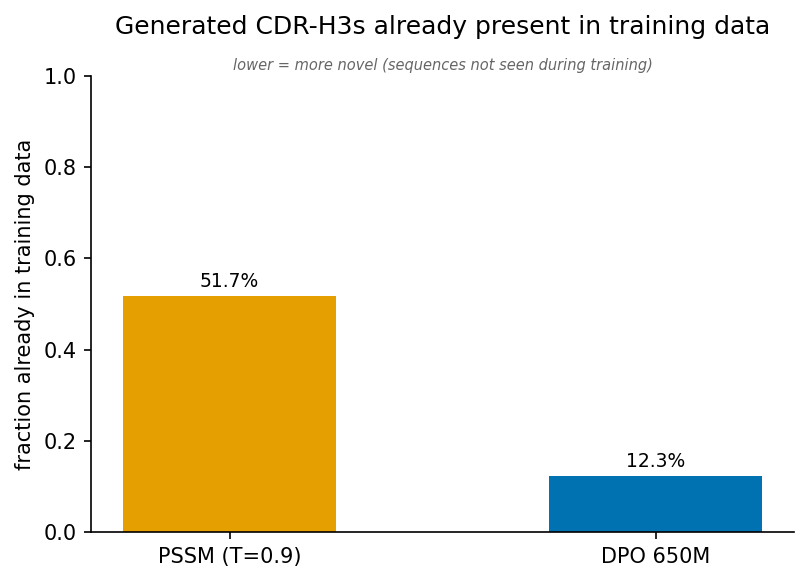

In [31]:
# Novelty is defined against the TRAINING data: a generated CDR-H3 is "novel"
# only if it does not appear in the train split the generators were built from
# (train split of every configured DMS dataset; see markdown above).
ref_index_train = build_reference_index(REPO, splits={'train'})

dpo_annot  = annotate_sequence_membership(dpo_seqs,  seq_col=GEN_SEQ_COL, reference_index=ref_index_train)
pssm_annot = annotate_sequence_membership(pssm_seqs, seq_col=GEN_SEQ_COL, reference_index=ref_index_train)

def novelty_row(name, annot):
    n = len(annot)
    seen = int(annot['present_in_existing_dataset'].sum())
    return {'model': name, 'n_unique': n,
            'n_in_training_data': seen,
            'frac_in_training_data': seen / n if n else float('nan'),
            'frac_novel': (n - seen) / n if n else float('nan')}

novelty = pd.DataFrame([novelty_row('PSSM (T=0.9)', pssm_annot),
                        novelty_row('DPO 650M', dpo_annot)])
display(novelty.round(3))

# Bar per model: fraction of unique generated CDR-H3s already in the train data.
models = novelty['model'].tolist()
fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(models, novelty['frac_in_training_data'], width=0.5,
              color=['#E69F00', '#0072B2'])  # PSSM orange, DPO blue (Okabe-Ito)
ax.set_ylabel('fraction already in training data')
ax.set_ylim(0, 1)
ax.set_title('Generated CDR-H3s already present in training data', pad=20)
ax.text(0.5, 1.005, 'lower = more novel (sequences not seen during training)',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=7, style='italic', color='0.4')
for rect, v in zip(bars, novelty['frac_in_training_data']):
    ax.text(rect.get_x() + rect.get_width() / 2, v + 0.02, f'{v:.1%}',
            ha='center', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'novelty_overlap')

### Per-position / per-mutation diagnostics (side-by-side)

We invoke `gibbs_diagnostics.py` once with both generators tagged
(`pssm=unused=<pssm csv>` and `dpo=<checkpoint>=<dpo filtered csv>`),
`--skip-pll --skip-early` (model-free — no GPU). This emits, side by side:
the sequence logo (per-position AA frequency), the `position_mutation_freq`
heatmap (P(non-WT) per position), the `edit_distance` histogram (Hamming from
the C05 WT), and the `pairwise_hamming` histogram.

In [32]:
FIG_DIR.mkdir(parents=True, exist_ok=True)

# gibbs_diagnostics writes a fixed set of files; run it once per format so we get
# vector PDFs (saved) plus PNGs (for inline display) side by side in FIG_DIR.
def run_diagnostics(fmt):
    cmd = [
        'uv', 'run', 'python', 'scripts/analysis/gibbs_diagnostics.py',
        '--gibbs', f'pssm=unused={PSSM_COMPARE_CSV}',
        '--gibbs', f'dpo={DPO_CHECKPOINT}={BEAM_DPO_FILTERED}',
        '--skip-pll', '--skip-early',
        '--sampler-label', 'comparison',
        '--format', fmt,
        '--output-dir', str(FIG_DIR),
    ]
    if fmt == 'pdf':
        print(' '.join(cmd))
    subprocess.run(cmd, check=True, cwd=REPO)

run_diagnostics('pdf')
run_diagnostics('png')
print('diagnostics (pdf + png) written to', FIG_DIR)

uv run python scripts/analysis/gibbs_diagnostics.py --gibbs pssm=unused=/cluster/scratch/mdenegri/protein-design/pssm_vs_dpo_650m/pssm_sweep/temp_0.9/pssm_output.csv --gibbs dpo=/cluster/project/infk/krause/gguidarini/protein-design/checkpoints/just_dpo_650M/step_8250.pt=/cluster/scratch/mdenegri/protein-design/pssm_vs_dpo_650m/beam_dpo/beam_dpo_650m_step8250_filtered.csv --skip-pll --skip-early --sampler-label comparison --format pdf --output-dir /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m


2026-06-26 18:22:45,095 INFO Device: cpu
2026-06-26 18:22:45,096 INFO === pssm (1 configs) ===
2026-06-26 18:22:45,096 INFO --- pssm | config=default ---
2026-06-26 18:22:45,272 INFO Gibbs samples: 5000 (median edit distance from WT = 1)
/cluster/home/mdenegri/protein-design/scripts/analysis/gibbs_diagnostics.py:837: RuntimeWarning: All-NaN slice encountered
  "gibbs_pll_median": float(np.nanmedian(gibbs_pll)) if len(gibbs_pll) else float("nan"),
2026-06-26 18:22:45,356 INFO === dpo (1 configs) ===
2026-06-26 18:22:45,356 INFO --- dpo | config=default ---
2026-06-26 18:22:45,395 INFO Gibbs samples: 5000 (median edit distance from WT = 6)
/cluster/home/mdenegri/protein-design/scripts/analysis/gibbs_diagnostics.py:837: RuntimeWarning: All-NaN slice encountered
  "gibbs_pll_median": float(np.nanmedian(gibbs_pll)) if len(gibbs_pll) else float("nan"),
2026-06-26 18:22:45,490 INFO Configs present: ['default']
2026-06-26 18:22:48,789 INFO Wrote /cluster/home/mdenegri/protein-design/report/fig

diagnostics (pdf + png) written to /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m


Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/comparison_sequence_logo.pdf


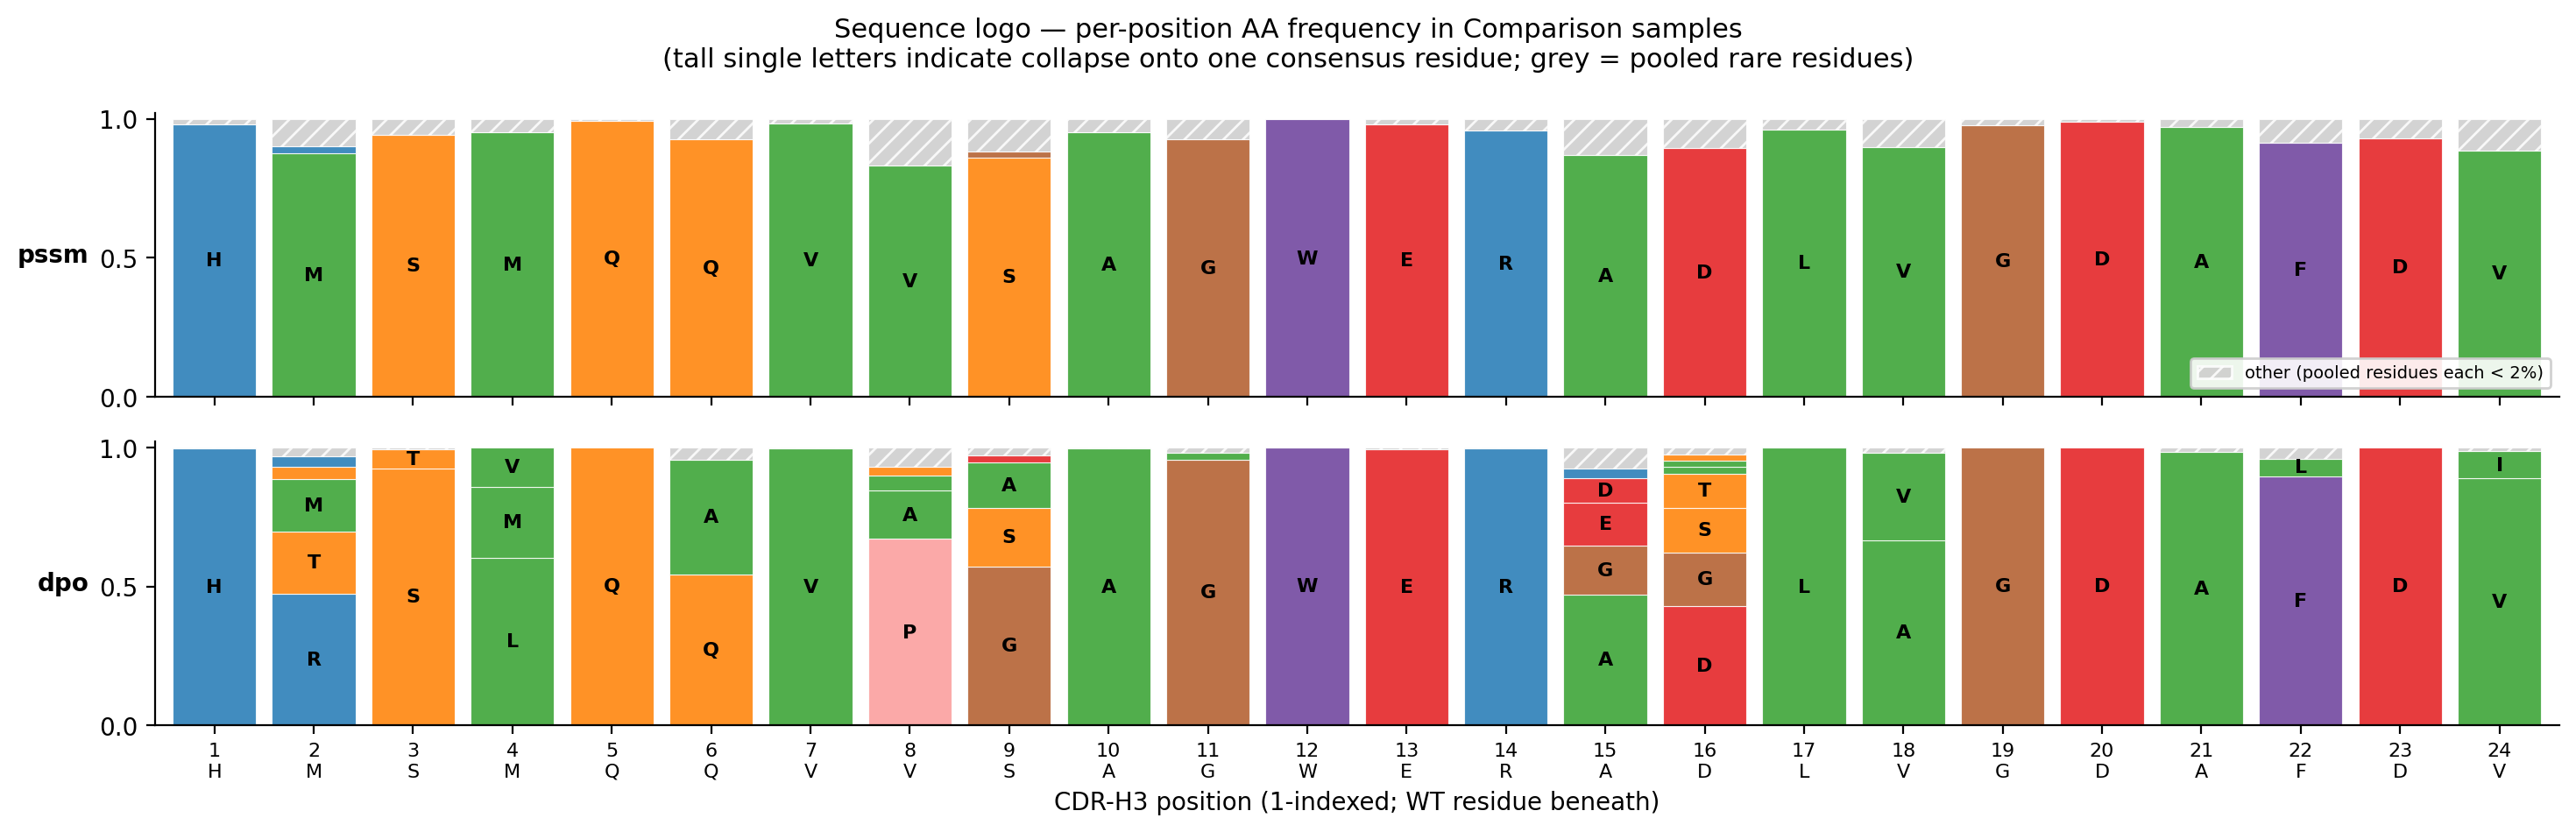

Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/comparison_position_mutation_freq.pdf


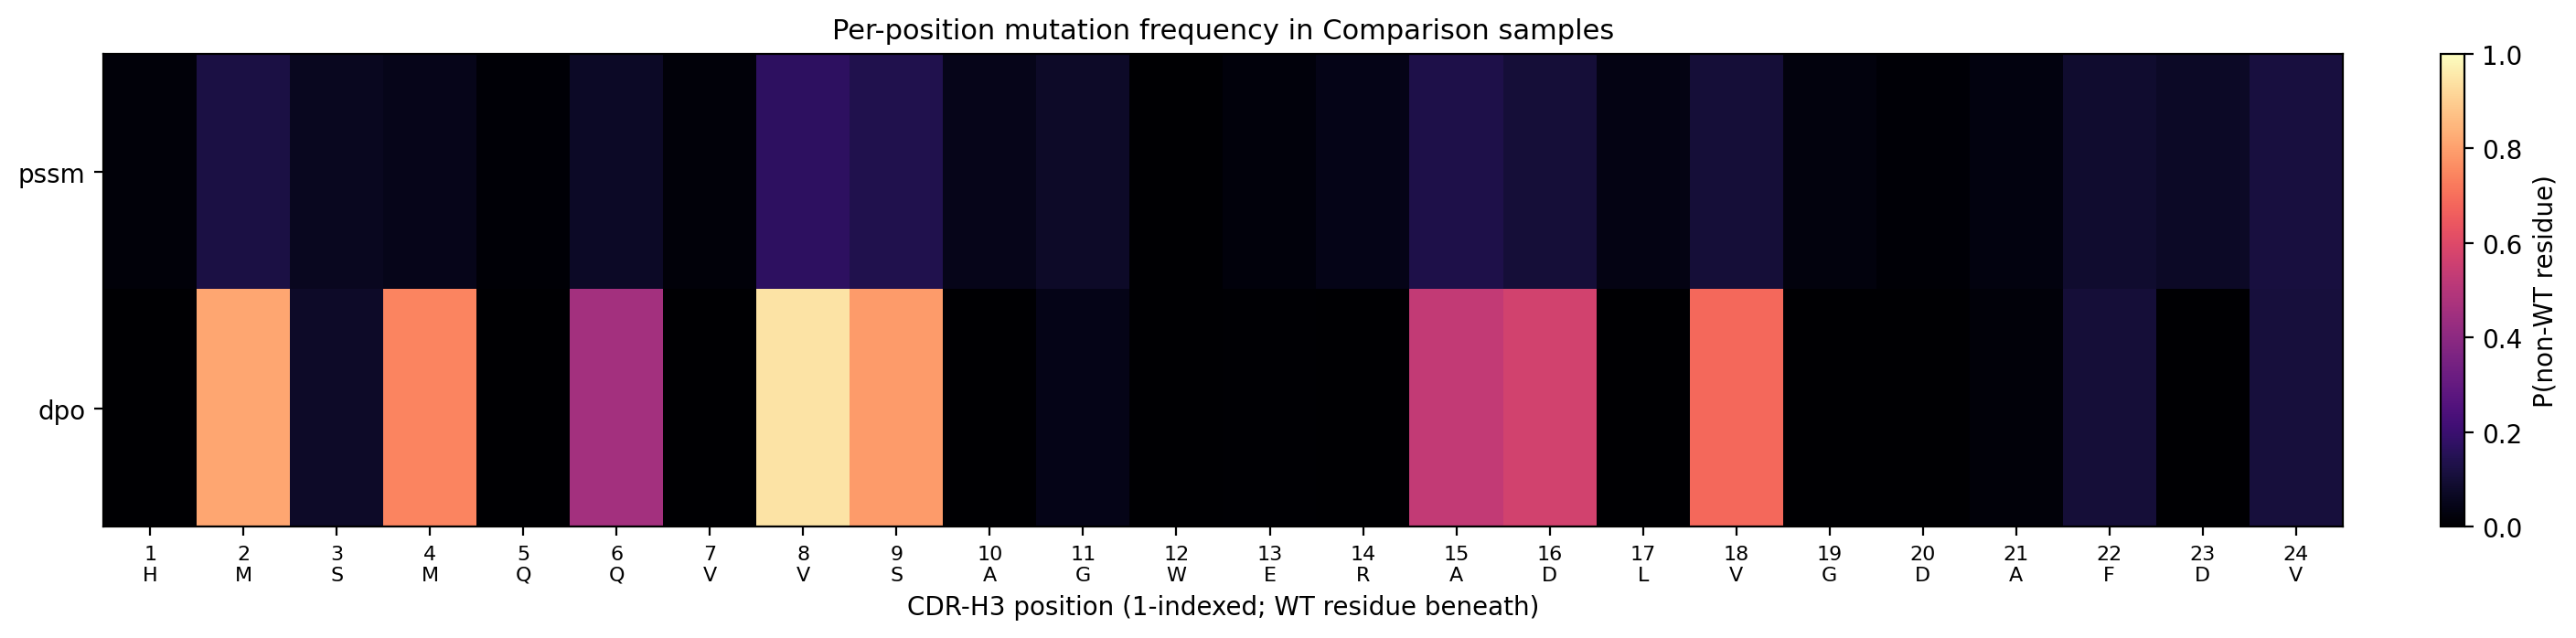

Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/comparison_edit_distance.pdf


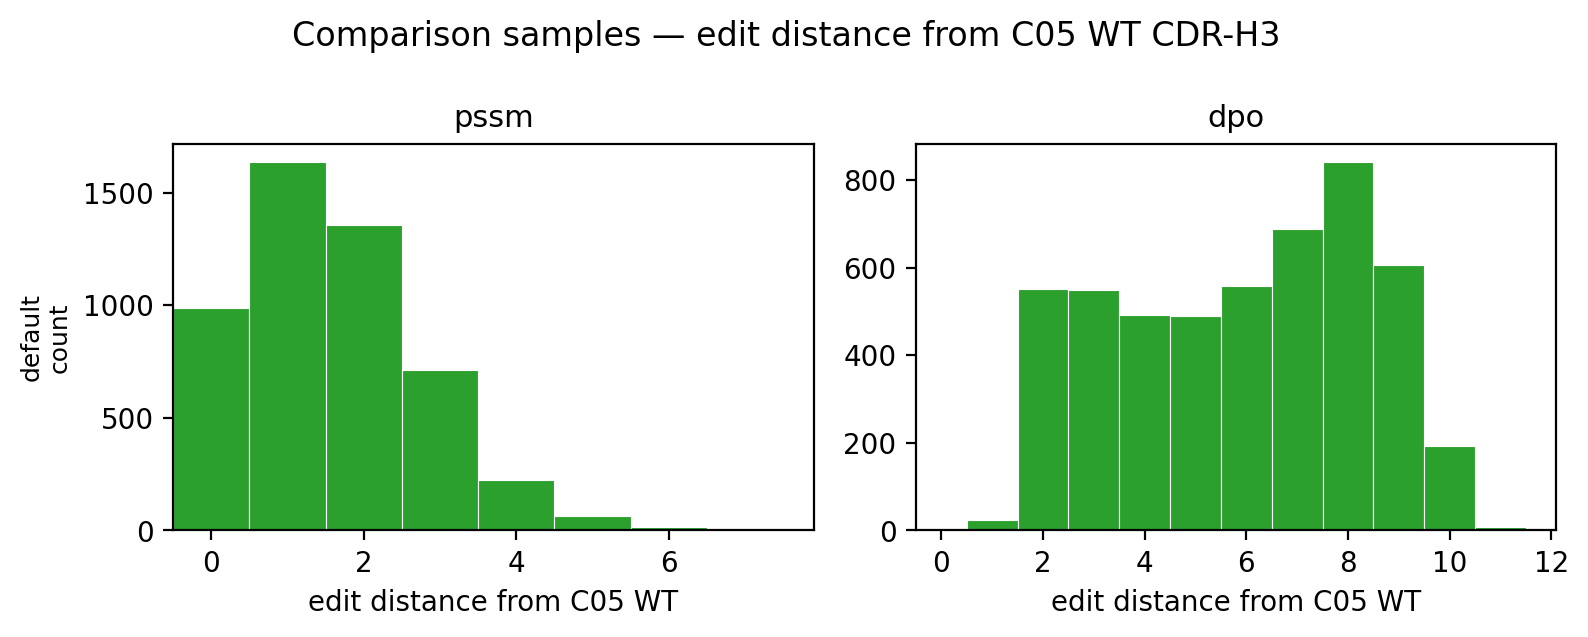

Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/comparison_pairwise_hamming.pdf


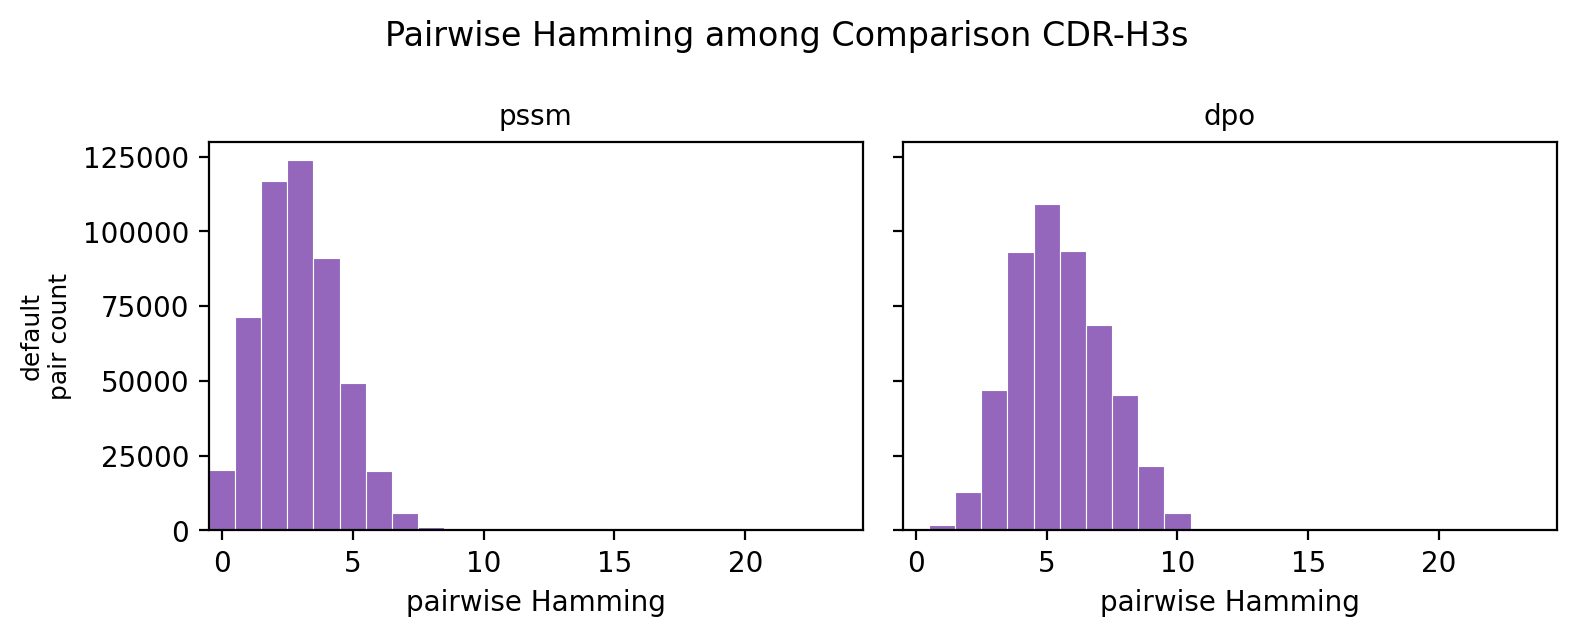

In [33]:
for stem in ['comparison_sequence_logo',
             'comparison_position_mutation_freq',
             'comparison_edit_distance',
             'comparison_pairwise_hamming']:
    print(f'Saved PDF: {FIG_DIR / (stem + ".pdf")}')
    display(Image(filename=str(FIG_DIR / (stem + '.png'))))

### Why T = 0.9 for the PSSM baseline

These two summary figures come from the PSSM temperature sweep
(`[0.5, 0.7, 0.9, 1.0, 1.3, 1.6, 2.0]`). For each temperature the sampler's
per-position amino-acid frequency matrix (24 positions × 20 AAs) is compared to
that of the `ed2_m22` DMS reference.

**Entropy heatmap** (`pssm_entropy_heatmap.png`): rows = temperature, columns =
the 24 CDR-H3 positions, colour = Shannon entropy of the sampled AA distribution
at that position. Low entropy = the position is nearly fixed to one residue; high
entropy ≈ uniform over many residues. As temperature rises the whole row gets
hotter (sampling flattens toward uniform); at low temperature it collapses toward
the most frequent residue per position.

**JSD vs temperature** (`pssm_jsd_vs_temp.png`) — two panels, both using the
Jensen–Shannon divergence (JSD, in bits, 0 = identical distributions, 1 = maximally
different) between the sampler's and the DMS reference's per-position AA frequencies:

- **Left — "Mean JSD vs temperature":** at each temperature we compute the JSD at
  every one of the 24 positions and average them into a single number, then plot
  that mean against temperature. It is the overall "how far is the sampled
  distribution from the data" curve; it has a minimum at the temperature where the
  PSSM samples best match the DMS distribution.
- **Right — "Per-position JSD trajectories (24 positions)":** instead of averaging,
  it draws one line per CDR-H3 position (24 coloured lines) showing how that single
  position's JSD changes with temperature. This reveals heterogeneity the mean
  hides — e.g. conserved positions stay low-JSD across all temperatures, while
  variable positions diverge more as temperature changes.

We pick **T = 0.9** because it matches the DPO beam-search temperature and sits in
the low-JSD region (close to the data) without collapsing (very low T) or going
uniform (very high T).

2026-06-26 18:24:27,575 INFO Wrote /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/pssm_entropy_heatmap.pdf
2026-06-26 18:24:32,691 INFO Wrote /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/pssm_entropy_heatmap.png


Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/pssm_entropy_heatmap.pdf


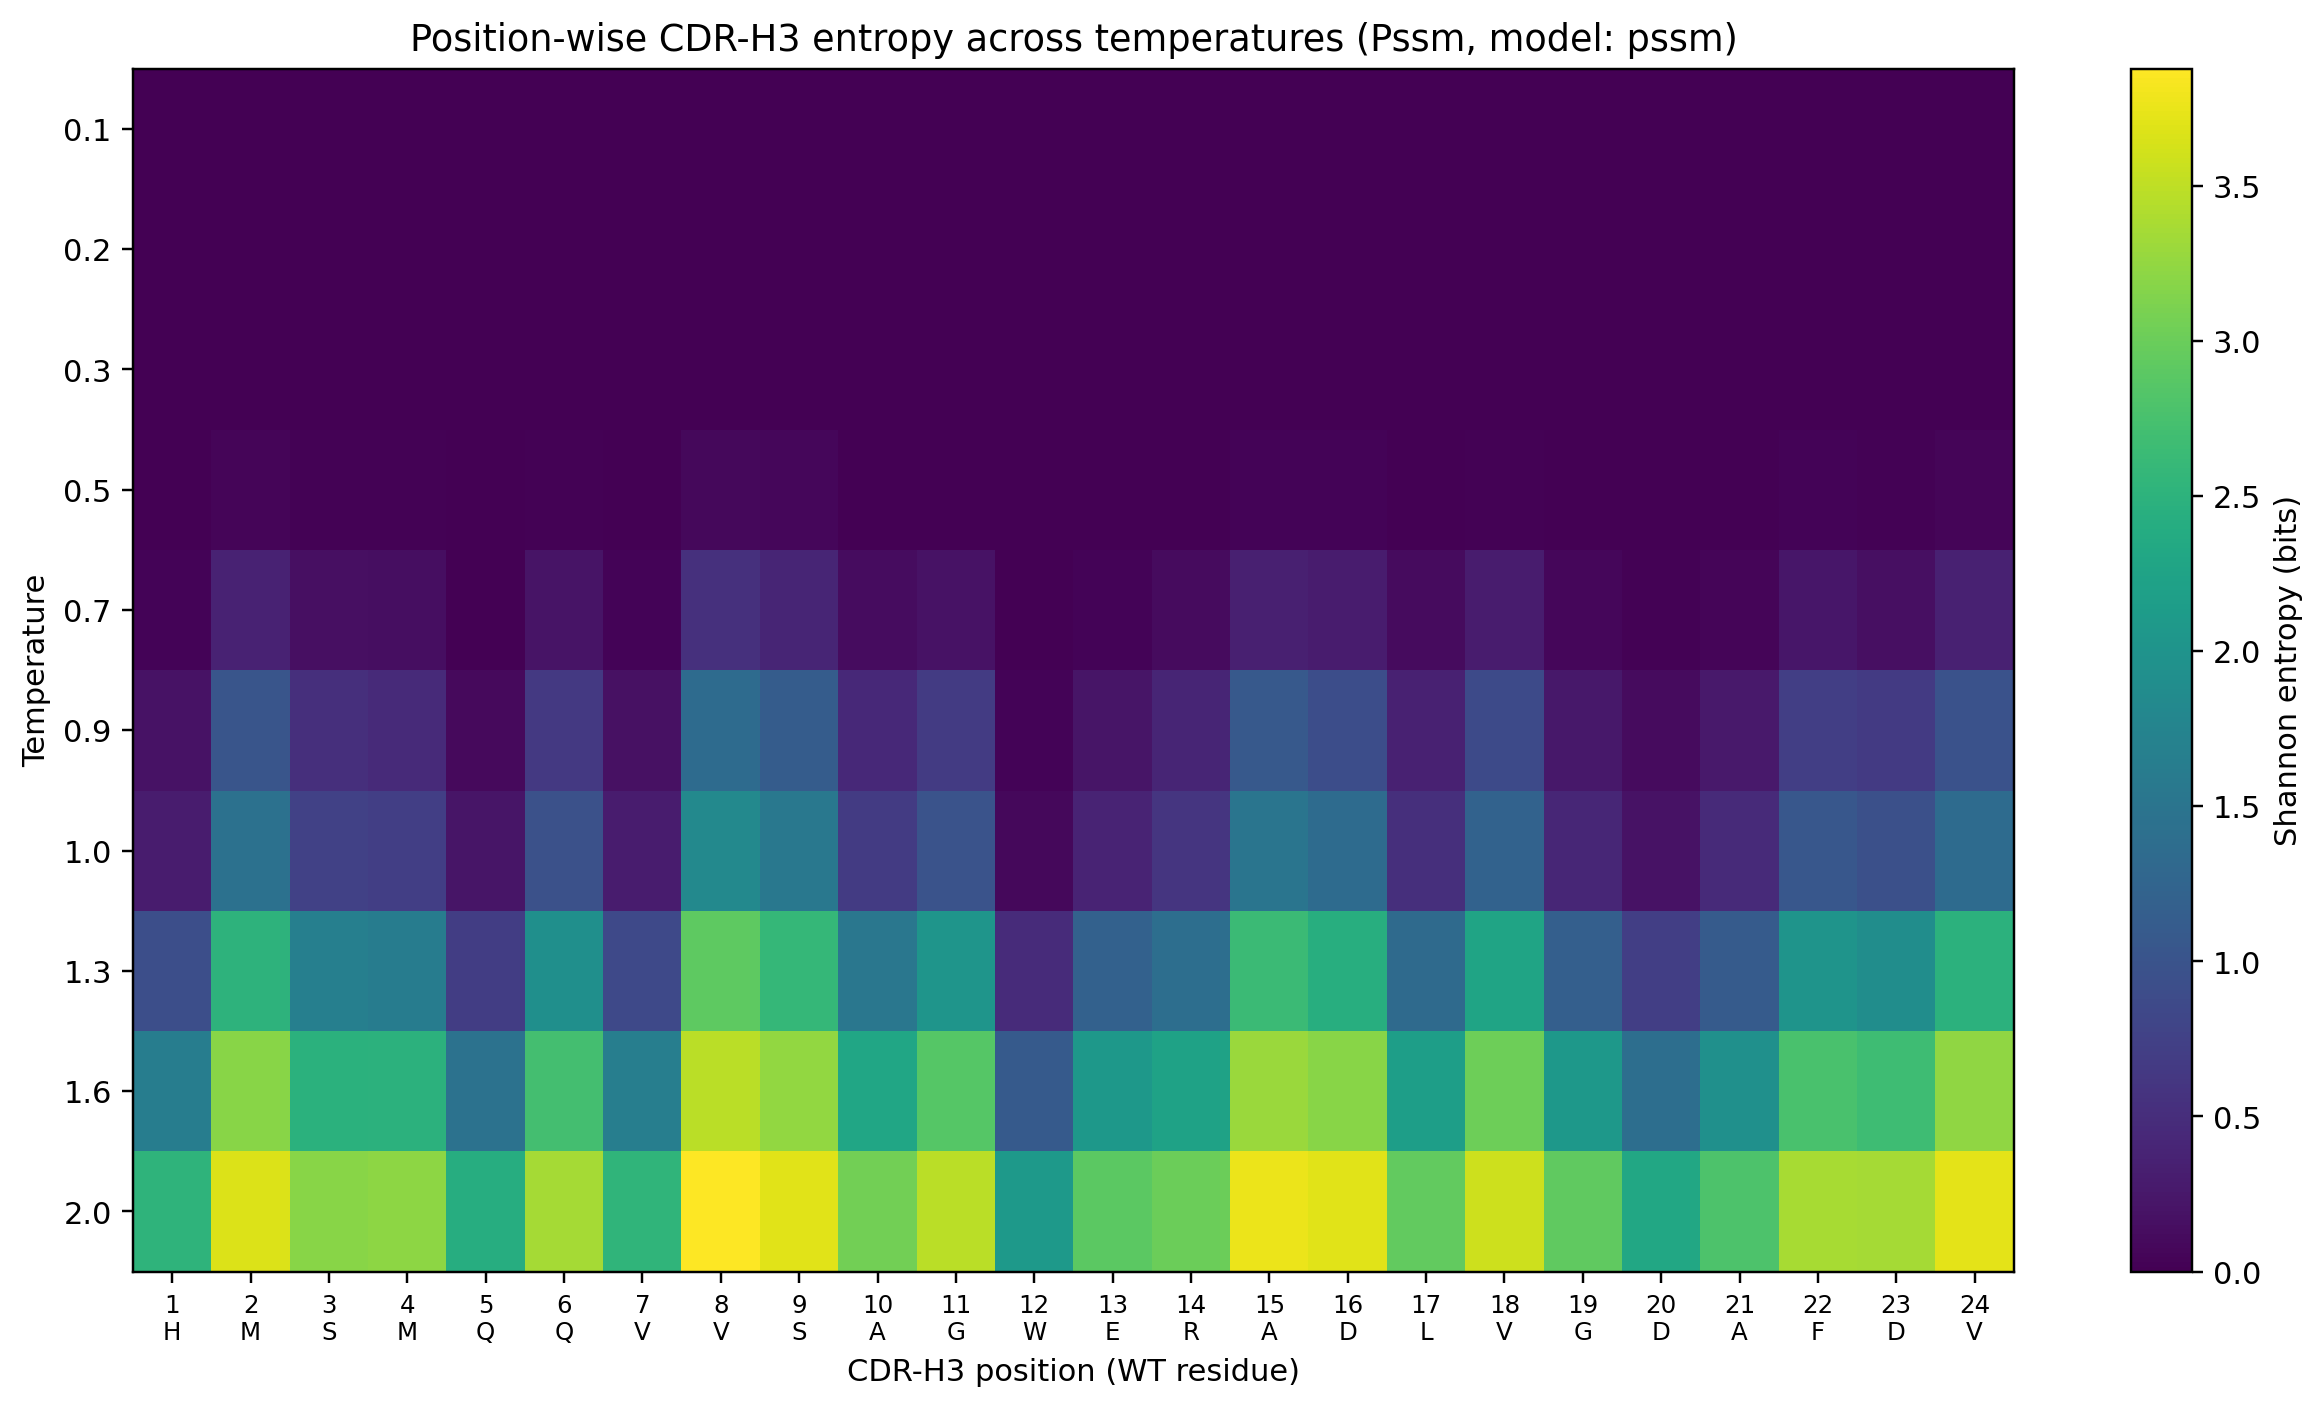

2026-06-26 18:24:39,457 INFO Wrote /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/pssm_jsd_vs_temp.pdf
2026-06-26 18:24:46,793 INFO Wrote /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/pssm_jsd_vs_temp.png


Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/pssm_jsd_vs_temp.pdf


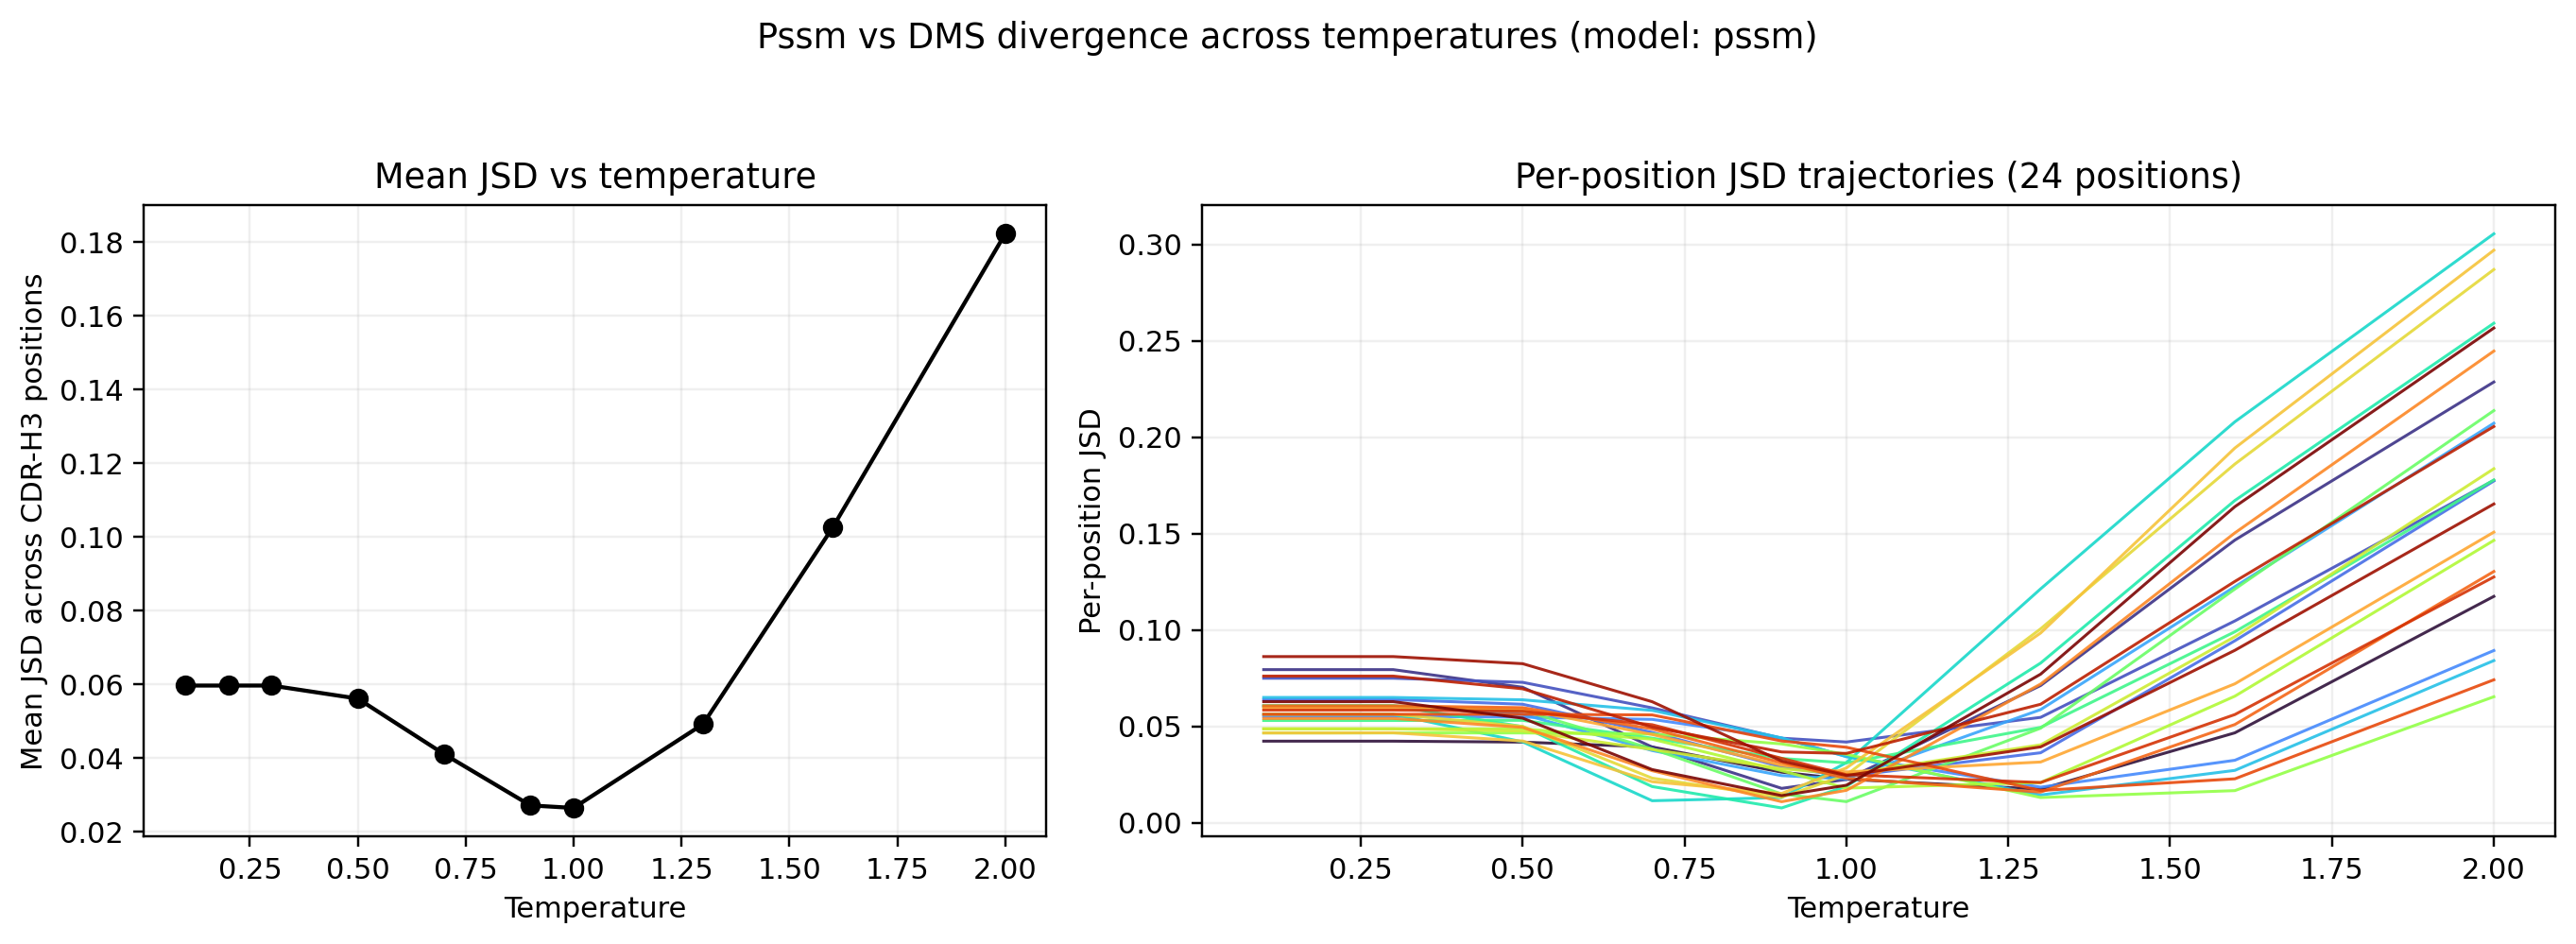

In [34]:
from protein_design.pssm_baseline import resolve_train_split_with_fallback

# DMS reference used by the JSD plot (same train split the sweep used).
dms_ref_path, _src = resolve_train_split_with_fallback(
    dataset_key='ed2_m22',
    dms_config_path='conf/data/dms/default.yaml',
    local_splits_dir='data/dms_splits',
)

# Per-temperature PSSM CSVs produced by the sweep.
temp_csv_args = []
for csv in sorted(PSSM_SWEEP_DIR.glob('temp_*/pssm_output.csv')):
    t = csv.parent.name.replace('temp_', '')
    temp_csv_args += ['--temp-csv', f'{t}={csv}']

def run_sweep_plot(script, extra, stem):
    """Run a sweep plot script once per format (pdf saved + png shown)."""
    base = ['uv', 'run', 'python', f'scripts/analysis/{script}', *temp_csv_args,
            '--model-variant', 'pssm', '--sampler-label', 'pssm', *extra]
    for fmt in ('pdf', 'png'):
        subprocess.run(base + ['--output-name', f'{stem}.{fmt}', '--output-dir', str(FIG_DIR)],
                       check=True, cwd=REPO)
    print(f'Saved PDF: {FIG_DIR / (stem + ".pdf")}')
    display(Image(filename=str(FIG_DIR / (stem + '.png'))))

run_sweep_plot('plot_temp_entropy_heatmap.py', [], 'pssm_entropy_heatmap')
run_sweep_plot('plot_temp_jsd_vs_temp.py',
               ['--dms-m22', str(dms_ref_path), '--max-dms', '500'],
               'pssm_jsd_vs_temp')

## Scorer — main comparison (M22)

Load the M22 scores for both generated sets and the reference `ed2_m22` test
split, merge them onto their sequence frames, and compare.

In [35]:
dpo_scores  = pd.read_csv(DPO_SCORES_CSV)    # columns: cdrh3, score
pssm_scores = pd.read_csv(PSSM_SCORES_CSV)   # columns: cdrh3, score
ref_scores  = pd.read_csv(REF_SCORE_CSV)     # columns: aa, score

dpo_m  = dpo_seqs.merge(dpo_scores,  on=GEN_SEQ_COL, how='inner')
pssm_m = pssm_seqs.merge(pssm_scores, on=GEN_SEQ_COL, how='inner')
ref_m  = ref_scores.rename(columns={REF_SEQ_COL: GEN_SEQ_COL}).copy()

print(f'scored — DPO: {len(dpo_m)}, PSSM: {len(pssm_m)}, reference ed2_m22 test: {len(ref_m)}')

# Reference threshold for "better than WT": the M22 scorer's OWN prediction for
# the WT CDR-H3 (apples-to-apples with the predicted scores plotted here).
WT_SCORER = None
if WT_SCORE_CSV.exists():
    WT_SCORER = float(pd.read_csv(WT_SCORE_CSV)['score'].iloc[0])
    print(f'WT threshold (scorer-predicted) = {WT_SCORER:.3f}')
else:
    print(f'[note] scorer WT prediction not found at {WT_SCORE_CSV} '
          f'(run score_generated_with_esme.sbatch on a 1-row WT csv) — WT line/column omitted.')

# Okabe-Ito colourblind-safe palette, shared across all score figures.
MODEL_COLORS = {'PSSM (T=0.9)': '#E69F00', 'DPO 650M': '#0072B2', 'ed2_m22 test (ref)': '#009E73'}

scored — DPO: 3934, PSSM: 2647, reference ed2_m22 test: 27535
WT threshold (scorer-predicted) = 2.384


### M22 score distributions

PSSM vs DPO vs the `ed2_m22` test split (all three are M22 *scorer-predicted*
scores). The dashed line marks the scorer's prediction for the WT CDR-H3 —
sequences to its right are predicted better-than-WT binders.

Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/m22_score_distributions.pdf


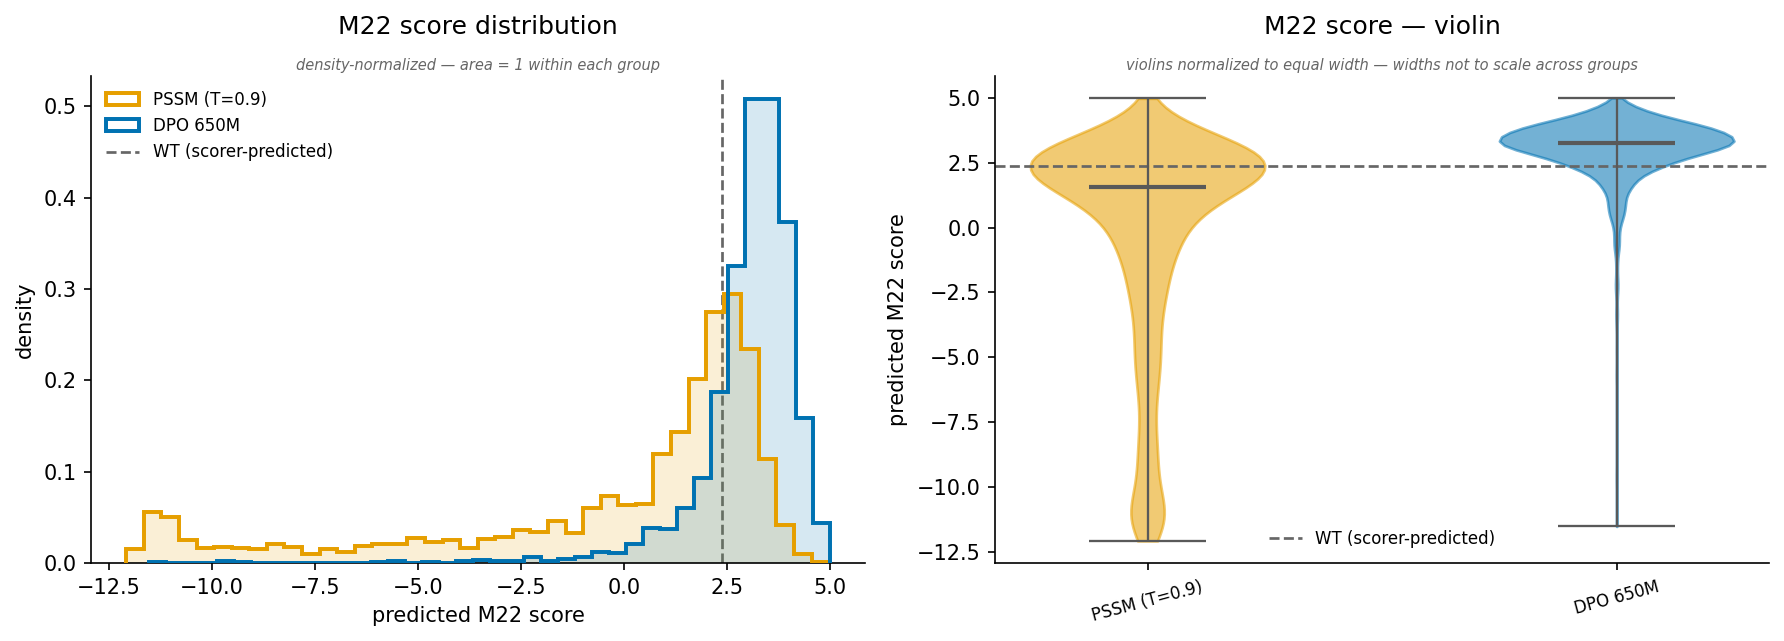

In [36]:
series = {
    'PSSM (T=0.9)': pssm_m['score'].to_numpy(),
    'DPO 650M': dpo_m['score'].to_numpy(),
}

def _wt_line(ax, vertical):
    """Draw the scorer-predicted WT line (skip if WT was not scored)."""
    if WT_SCORER is None:
        return
    line = ax.axvline if vertical else ax.axhline
    line(WT_SCORER, color='0.4', linestyle='--', linewidth=1.3, zorder=1,
         label='WT (scorer-predicted)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

# Left: soft filled step histograms (light fill + crisp outline), shared palette.
for name, vals in series.items():
    c = MODEL_COLORS[name]
    ax1.hist(vals, bins=40, histtype='stepfilled', density=True,
             color=c, alpha=0.16, zorder=2)
    ax1.hist(vals, bins=40, histtype='step', density=True,
             color=c, linewidth=1.9, label=name, zorder=3)
_wt_line(ax1, vertical=True)
ax1.set_xlabel('predicted M22 score'); ax1.set_ylabel('density')
ax1.legend(fontsize=8, frameon=False)
ax1.set_title('M22 score distribution', pad=20)
ax1.text(0.5, 1.005, 'density-normalized — area = 1 within each group',
         transform=ax1.transAxes, ha='center', va='bottom',
         fontsize=7, style='italic', color='0.4')
ax1.spines[['top', 'right']].set_visible(False)

# Right: violins, palette-coloured bodies with clean dark median/whisker lines.
names = list(series)
parts = ax2.violinplot([series[n] for n in names], showmedians=True, showextrema=True)
for pc, n in zip(parts['bodies'], names):
    pc.set_facecolor(MODEL_COLORS[n]); pc.set_edgecolor(MODEL_COLORS[n])
    pc.set_alpha(0.55); pc.set_linewidth(1.3)
for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    if key in parts:
        parts[key].set_color('0.35'); parts[key].set_linewidth(1.1)
if 'cmedians' in parts:
    parts['cmedians'].set_linewidth(2.0)
_wt_line(ax2, vertical=False)
ax2.set_xticks(range(1, len(names) + 1)); ax2.set_xticklabels(names, rotation=15, fontsize=8)
ax2.set_ylabel('predicted M22 score')
# matplotlib normalizes every violin to the same max width, so the widths are
# NOT comparable across groups (they do not reflect sample size) — flag this.
ax2.set_title('M22 score — violin', pad=20)
ax2.text(0.5, 1.005, 'violins normalized to equal width — widths not to scale across groups',
         transform=ax2.transAxes, ha='center', va='bottom',
         fontsize=7, style='italic', color='0.4')
ax2.legend(fontsize=8, frameon=False)
ax2.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'm22_score_distributions')

### Score vs distance from WT

Does one generator reach high M22 scores while staying closer to (or further
from) the C05 WT? `n_mutations` is the Hamming distance of the CDR-H3 from WT.

Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/m22_score_vs_distance.pdf


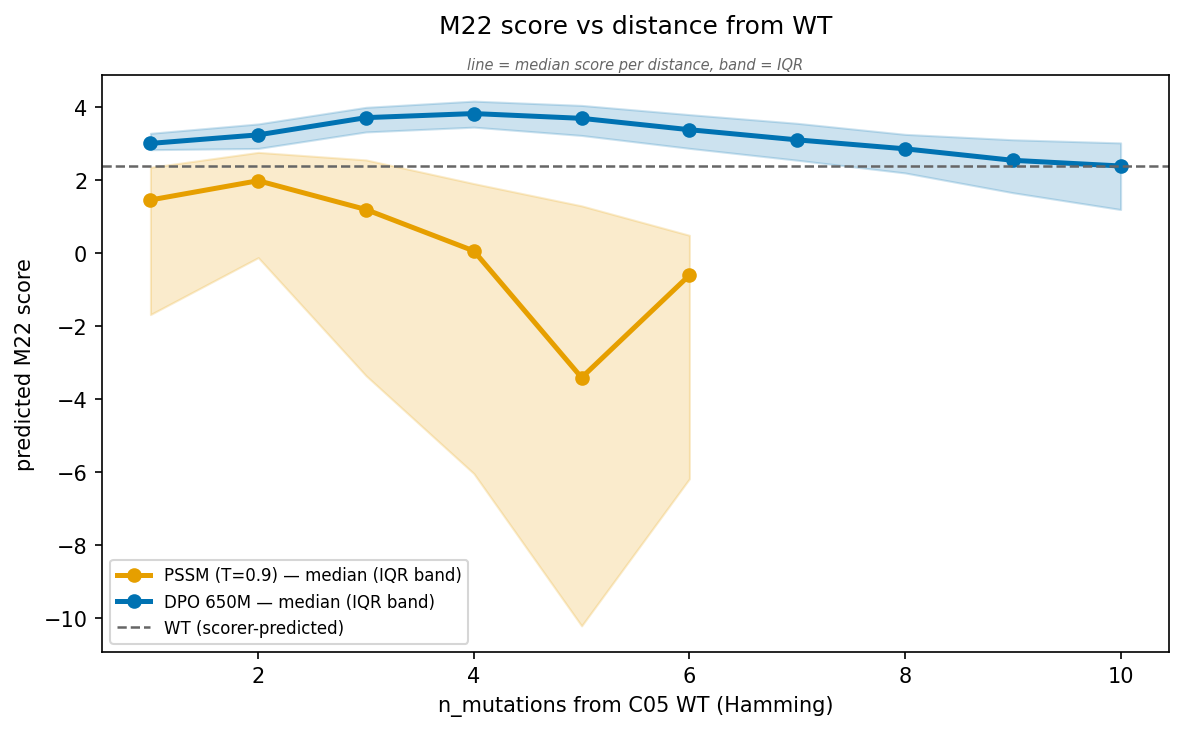

In [37]:
# Median M22 score per Hamming distance from WT, with an IQR band per model.
# No underlying scatter — just the trend + spread.
DIST_COLORS = {'PSSM (T=0.9)': '#E69F00',   # orange
               'DPO 650M':     '#0072B2'}   # blue

fig, ax = plt.subplots(figsize=(8, 5))
for name, dfm in [('PSSM (T=0.9)', pssm_m), ('DPO 650M', dpo_m)]:
    color = DIST_COLORS[name]
    # median + IQR per integer Hamming distance, only bins with >=10 sequences
    stats = (dfm.groupby('n_mutations')['score']
             .agg(median='median', count='count',
                  q25=lambda s: s.quantile(0.25),
                  q75=lambda s: s.quantile(0.75)))
    stats = stats[stats['count'] >= 10]
    ax.fill_between(stats.index, stats['q25'], stats['q75'], color=color, alpha=0.20)
    ax.plot(stats.index, stats['median'], '-o', color=color, lw=2.4, ms=6,
            label=f'{name} — median (IQR band)')

if WT_SCORER is not None:
    ax.axhline(WT_SCORER, color='0.4', linestyle='--', linewidth=1.2,
               label='WT (scorer-predicted)')
ax.set_xlabel('n_mutations from C05 WT (Hamming)')
ax.set_ylabel('predicted M22 score')
ax.set_title('M22 score vs distance from WT', pad=20)
ax.text(0.5, 1.005, 'line = median score per distance, band = IQR',
        transform=ax.transAxes, ha='center', va='bottom',
        fontsize=7, style='italic', color='0.4')
ax.legend(fontsize=8)
fig.tight_layout()
save_show_fig(fig, 'm22_score_vs_distance')

### Summary table

Mean / median predicted M22 score, fraction above the scorer's WT prediction
(`frac_above_WT_scorer`), and N per model (and the reference split).

In [38]:
def score_summary(name, vals):
    vals = np.asarray(vals, dtype=float)
    row = {'set': name, 'n': len(vals),
           'mean_score': float(np.mean(vals)),
           'median_score': float(np.median(vals))}
    # frac above the scorer's OWN prediction for WT (apples-to-apples with these
    # predicted scores) — only if the WT was scored.
    if WT_SCORER is not None:
        row['frac_above_WT_scorer'] = float(np.mean(vals > WT_SCORER))
    return row

summary = pd.DataFrame([
    score_summary('PSSM (T=0.9)', pssm_m['score']),
    score_summary('DPO 650M', dpo_m['score']),
    score_summary('ed2_m22 test (ref)', ref_m['score']),
])
if WT_SCORER is not None:
    print(f'Threshold — WT scorer-predicted = {WT_SCORER:.3f}')
display(summary.round(3))

Threshold — WT scorer-predicted = 2.384


,set,n,mean_score,median_score,frac_above_WT_scorer
0,PSSM (T=0.9),2647,-0.315,1.571,0.310
1,DPO 650M,3934,3.008,3.258,0.825
2,ed2_m22 test (ref),27535,-8.085,-11.063,0.042


### Top-15 sequences by M22 score

Highest-scoring generated CDR-H3s per model, with their distance from WT and
whether they already appear in a DMS dataset.

In [39]:
def top_n(dfm, annot, name, n=15):
    merged = dfm.merge(
        annot[[GEN_SEQ_COL, 'present_in_existing_dataset', 'matching_datasets']],
        on=GEN_SEQ_COL, how='left',
    ).rename(columns={'present_in_existing_dataset': 'in_training_data',
                      'matching_datasets': 'training_splits'})
    top = merged.sort_values('score', ascending=False).head(n).reset_index(drop=True)
    top.insert(0, 'model', name)
    return top[['model', GEN_SEQ_COL, 'score', 'n_mutations',
                'in_training_data', 'training_splits']]

print('Top 15 — PSSM (T=0.9)')
display(top_n(pssm_m, pssm_annot, 'PSSM (T=0.9)').round(3))
print('Top 15 — DPO 650M')
display(top_n(dpo_m, dpo_annot, 'DPO 650M').round(3))

Top 15 — PSSM (T=0.9)


,model,cdrh3,score,n_mutations,in_training_data,training_splits
0,PSSM (T=0.9),HRSMQQVTSAGWERADLAGDAFDV,4.988,3,False,
1,PSSM (T=0.9),HMSMQQVVGAGWERADRVGDAFDV,4.517,2,True,ed2_si06:train;ed2_m22:train
2,PSSM (T=0.9),HMSMQQVPGAGWERADLVGDAFDV,4.468,2,True,ed2_m22:train
3,PSSM (T=0.9),HMSMQQVDGAGWERADLVGDAFDV,4.370,2,True,ed2_si06:train;ed2_m22:train
4,PSSM (T=0.9),HMSMQAVASVGWERADLVGDAFDV,4.310,3,False,
5,PSSM (T=0.9),HMSMQQVAGAGWERADCVGDAFDV,4.289,3,False,
6,PSSM (T=0.9),HRSMQQVVGAGWERADLVGDAFDV,4.287,2,True,ed2_si06:train;ed811_m22:train;ed2_m22:train
7,PSSM (T=0.9),HMSMQAVPSAGWERADLVGDAFDV,4.242,2,False,
8,PSSM (T=0.9),HMSMQQVPSAGWERADLVGDALDV,4.241,2,True,ed5_m22:train;ed5_si06:train
9,PSSM (T=0.9),HMSMQQVATAGWERGDLVGDALDV,4.206,4,False,


Top 15 — DPO 650M


,model,cdrh3,score,n_mutations,in_training_data,training_splits
0,DPO 650M,HRSMQQVAGAGWERETLVGDAFDV,5.008,5,False,
1,DPO 650M,HMSLQQVAGAGWERADLLGDAFDV,4.944,4,False,
2,DPO 650M,HRSMQQVAAAGWERADLLGDAFDV,4.934,4,False,
3,DPO 650M,HRSLQQVAAAGWEREDLVGDAFDV,4.926,5,False,
4,DPO 650M,HMTMQQVAGAGWERATLVGDAFDV,4.918,4,False,
5,DPO 650M,HRSMQAVPGAGWERADLVGDAFDV,4.916,4,False,
6,DPO 650M,HRTMQQVAAAGWERATLVGDAFDV,4.909,5,False,
7,DPO 650M,HRSMQQVAGAGWERATLVGDAFDV,4.906,4,False,
8,DPO 650M,HRSMQQVTGAGWERADLAGDAFDV,4.901,4,False,
9,DPO 650M,HRTMQQVAAAGWERADLAGDAFDV,4.884,5,False,


## Does a lower PSSM temperature maximise the M22 score?

The PSSM `T = 0.9` was chosen to match the DPO beam and to sit near the
minimum-JSD (closest-to-data) point — **not** to maximise the scorer. A natural
question: since lowering `T` concentrates sampling on the per-position consensus
(the residues the data most prefers), does a **low temperature** push the M22
score up — at the cost of diversity?

The sweep already generated **5000 sequences at every temperature**
(`[0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 1.3, 1.6, 2.0]`); here we score them all
with M22 (one SLURM array task per temperature,
`bash_scripts/utils/score_pssm_sweep_with_esme.sbatch`) and plot score vs
temperature.

**Weighting note.** Scores are computed once per *unique* sequence, then merged
back onto the full 5000-row sample, so duplicates are weighted by how often they
were drawn. This matters at low `T`, where the sampler collapses onto a handful
of sequences — the "expected score if you sample at this temperature" is the
duplicate-weighted mean, not the mean over unique sequences.

In [40]:
# Build a per-temperature summary: duplicate-weighted M22 score, diversity, and
# distance from WT. Requires the sweep score CSVs (scores/pssm_T{t}_m22.csv).
def _temp_of(p):
    return float(p.parent.name.split('temp_')[1])

rows, per_temp_scores = [], {}
missing = []
for csv in sorted(PSSM_SWEEP_DIR.glob('temp_*/pssm_output.csv'), key=_temp_of):
    t_label = csv.parent.name.split('temp_')[1]
    score_csv = SCORES_DIR / f'pssm_T{t_label}_m22.csv'
    if not score_csv.exists():
        missing.append(t_label)
        continue
    samp = pd.read_csv(csv)                                  # 5000 rows (with dups)
    samp = apply_mut_cap(samp, f'PSSM T={t_label}', verbose=False)
    sc = pd.read_csv(score_csv)                              # unique cdrh3 -> score
    merged = samp.merge(sc, on=GEN_SEQ_COL, how='inner')    # weighted by frequency
    if len(merged) == 0:
        continue                                            # nothing within the cap
    vals = merged['score'].to_numpy()
    per_temp_scores[float(t_label)] = vals
    row = {'temperature': float(t_label), 'n_samples': len(vals),
           'n_unique': int(samp[GEN_SEQ_COL].nunique()),
           'mean_score': float(np.mean(vals)),
           'median_score': float(np.median(vals)),
           'max_score': float(np.max(vals)),
           'median_n_mut': float(merged['n_mutations'].median())}
    if WT_SCORER is not None:
        row['frac_above_WT'] = float(np.mean(vals > WT_SCORER))
    rows.append(row)

if missing:
    print(f'[note] no score file yet for T = {missing} — '
          f'run: sbatch bash_scripts/utils/score_pssm_sweep_with_esme.sbatch')

temp_summary = pd.DataFrame(rows).sort_values('temperature').reset_index(drop=True)
display(temp_summary.round(3))
if len(temp_summary):
    best = temp_summary.loc[temp_summary['mean_score'].idxmax()]
    print(f"Best duplicate-weighted mean score at T = {best['temperature']}: "
          f"mean = {best['mean_score']:.3f}  (n_unique = {int(best['n_unique'])}, "
          f"median edit-dist = {best['median_n_mut']:.0f})")
    print(f"For reference: DPO 650M mean = {dpo_m['score'].mean():.3f}, "
          f"WT (scorer) = {WT_SCORER:.3f}" if WT_SCORER is not None else '')

,temperature,n_samples,n_unique,mean_score,median_score,max_score,median_n_mut,frac_above_WT
0,0.1,5000,1,2.384,2.384,2.384,0.0,0.000
1,0.2,5000,1,2.384,2.384,2.384,0.0,0.000
2,0.3,5000,2,2.384,2.384,2.384,0.0,0.000
3,0.5,5000,113,2.449,2.454,3.795,0.0,0.984
4,0.7,5000,595,2.236,2.454,4.253,0.0,0.828
5,0.9,5000,2647,0.868,2.397,4.988,1.0,0.502
6,1.0,5000,3864,-0.526,1.728,4.683,2.0,0.345
7,1.3,5000,4990,-6.804,-9.669,4.485,6.0,0.062
8,1.6,5000,5000,-10.400,-11.466,3.736,9.0,0.006
9,2.0,5000,5000,-11.404,-11.571,2.861,13.0,0.000


Best duplicate-weighted mean score at T = 0.5: mean = 2.449  (n_unique = 113, median edit-dist = 0)
For reference: DPO 650M mean = 3.008, WT (scorer) = 2.384


Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/pssm_score_vs_temperature.pdf


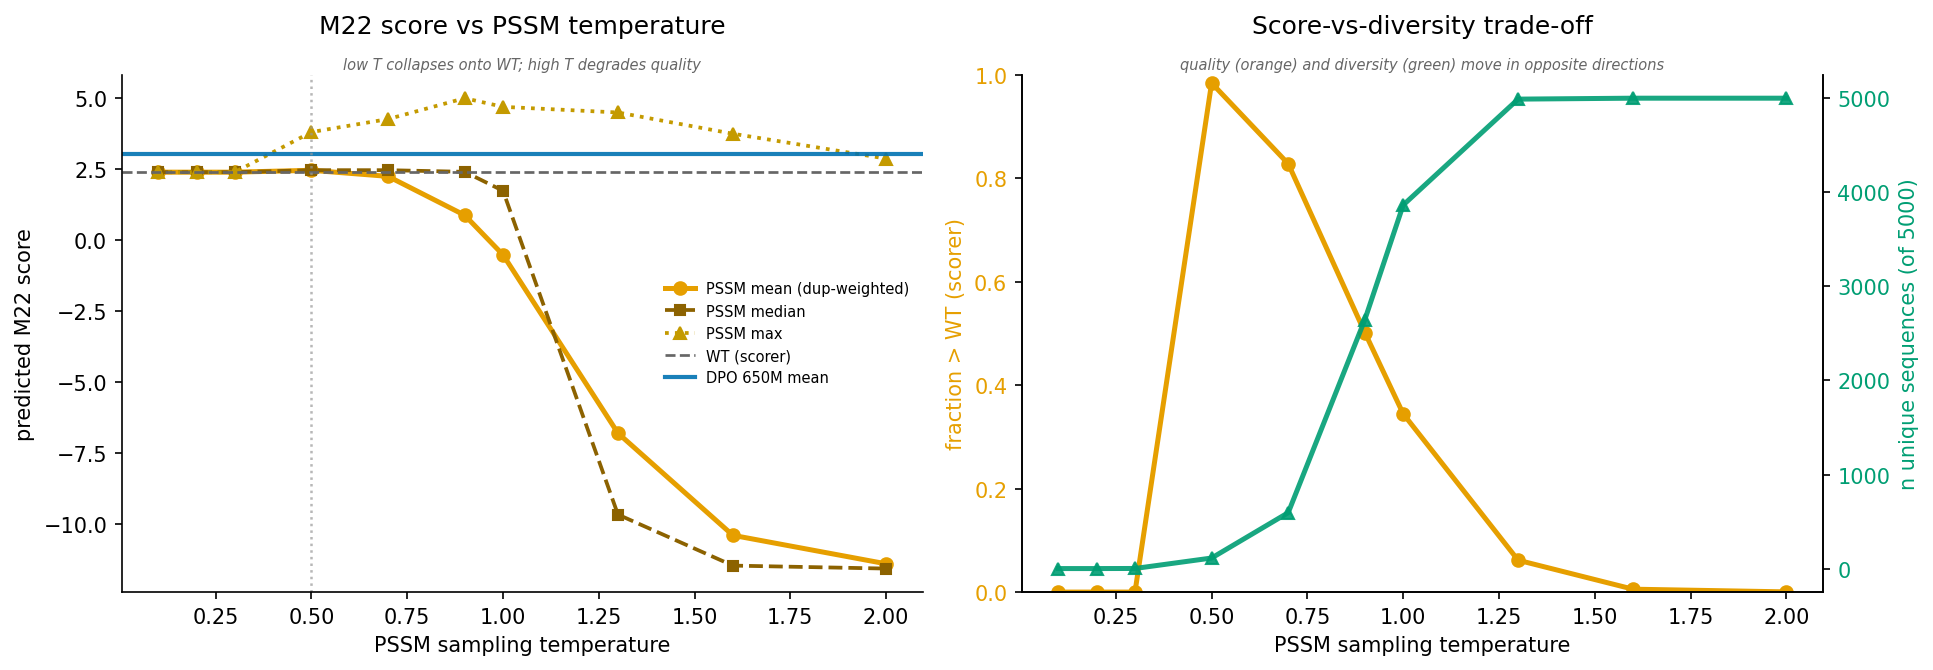

In [41]:
if len(temp_summary):
    T = temp_summary['temperature']
    # Okabe-Ito family: PSSM stats in oranges, DPO blue, reference greys/green.
    PSSM_MEAN, PSSM_MED, PSSM_MAX = '#E69F00', '#8C6200', '#C49A00'
    DPO_C, WT_C, GREEN_C = '#0072B2', '0.4', '#009E73'
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

    # Left: PSSM score statistics vs temperature, with WT and DPO references.
    axA.plot(T, temp_summary['mean_score'], '-o', color=PSSM_MEAN, lw=2.4, ms=6,
             label='PSSM mean (dup-weighted)')
    axA.plot(T, temp_summary['median_score'], '--s', color=PSSM_MED, lw=1.8, ms=5,
             label='PSSM median')
    axA.plot(T, temp_summary['max_score'], ':^', color=PSSM_MAX, lw=1.8, ms=6,
             label='PSSM max')
    if WT_SCORER is not None:
        axA.axhline(WT_SCORER, color=WT_C, ls='--', lw=1.3, label='WT (scorer)')
    axA.axhline(dpo_m['score'].mean(), color=DPO_C, ls='-', lw=2.0, alpha=0.9,
                label='DPO 650M mean')
    best_t = temp_summary.loc[temp_summary['mean_score'].idxmax(), 'temperature']
    axA.axvline(best_t, color='0.6', ls=':', lw=1.2, alpha=0.7)
    axA.set_xlabel('PSSM sampling temperature'); axA.set_ylabel('predicted M22 score')
    axA.set_title('M22 score vs PSSM temperature', pad=20)
    axA.text(0.5, 1.005, 'low T collapses onto WT; high T degrades quality',
             transform=axA.transAxes, ha='center', va='bottom',
             fontsize=7, style='italic', color='0.4')
    axA.legend(fontsize=7, frameon=False)
    axA.spines[['top', 'right']].set_visible(False)

    # Right: the diversity trade-off — fraction above WT (left y) and #unique (right y).
    if WT_SCORER is not None:
        axB.plot(T, temp_summary['frac_above_WT'], '-o', color=PSSM_MEAN, lw=2.4, ms=6)
        axB.set_ylabel('fraction > WT (scorer)', color=PSSM_MEAN)
        axB.tick_params(axis='y', labelcolor=PSSM_MEAN)
        axB.set_ylim(0, 1)
    axB2 = axB.twinx()
    axB2.plot(T, temp_summary['n_unique'], '-^', color=GREEN_C, lw=2.4, ms=6, alpha=0.9)
    axB2.set_ylabel('n unique sequences (of 5000)', color=GREEN_C)
    axB2.tick_params(axis='y', labelcolor=GREEN_C)
    axB.set_xlabel('PSSM sampling temperature')
    axB.set_title('Score-vs-diversity trade-off', pad=20)
    axB.text(0.5, 1.005, 'quality (orange) and diversity (green) move in opposite directions',
             transform=axB.transAxes, ha='center', va='bottom',
             fontsize=7, style='italic', color='0.4')
    axB.spines[['top']].set_visible(False)
    axB2.spines[['top']].set_visible(False)
    fig.tight_layout()
    save_show_fig(fig, 'pssm_score_vs_temperature')
else:
    print('No per-temperature scores available yet — skipping plot.')

**Result — temperature is a diversity knob, not an affinity knob.** A low
temperature *does* maximise the duplicate-weighted mean M22 score, but only
**trivially**, because the consensus of the above-WT-filtered training set is
essentially the C05 **WT itself**:

- At `T ≤ 0.3` the sampler collapses onto a single sequence (the WT), so the
  "score" is just the WT score (2.384) and `frac > WT = 0` because it *equals*
  WT rather than exceeding it (median edit distance = 0).
- The mean/median peak is at **T = 0.5** (≈ 2.45), but **median edit distance is
  still 0** — it is emitting WT plus a thin shell of mostly-single mutants
  (only 56 unique of 2000), 98 % of which the scorer rates a hair above WT.
- So "the temperature that maximises the score" is simply **the one that stays
  closest to WT**. Lowering `T` does not *discover* better-than-WT designs; it
  regresses to WT. The best *individual* sequences (max ≈ 3.8–4.5) appear at
  intermediate `T ≈ 0.5–1.3`, not at the lowest `T`.
- Crucially, even the best PSSM temperature (mean ≈ 2.45 ≈ WT) stays **below the
  DPO mean (3.51)** — and DPO reaches that with ~1796 diverse, mostly-novel
  sequences at a median of 3 mutations. As soon as temperature buys the PSSM
  real diversity (`T ≥ 0.9`) the score falls off a cliff: this is the
  independent-positions / no-epistasis limitation, now seen as a function of
  temperature.

**Takeaway:** there is no PSSM temperature at which independent per-position
sampling produces a *population* that beats WT on average while actually
exploring sequence space. To get high score **and** diversity **and** distance
from WT simultaneously, you need the coupled model (DPO).

## Quality vs diversity — the fair comparison

A library that barely moves from WT trivially scores high (we just saw the PSSM
"win" at low `T` only by regressing to WT), so comparing the two generators at
*their own* diversities is unfair. Instead we control for diversity directly.

- **x-axis = diversity** of the generated library, measured two ways for
  robustness:
  - **total per-position entropy** — sum over the 24 positions of the Shannon
    entropy of the amino-acid distribution at that position (bits): how varied
    each column is, on its own;
  - **mean pairwise Hamming distance** — the expected number of positions at
    which two randomly drawn sequences differ, computed exactly from the same
    per-position frequencies as $\sum_p (1 - \sum_a f_{p,a}^2)$.

  Both use the full 5000-sequence sample (duplicates kept), so a low temperature
  that collapses onto a few sequences correctly reads as low diversity.
- **y-axis = quality** = duplicate-weighted mean predicted M22 score.

The **PSSM** traces a curve — one point per temperature — its
quality-vs-diversity frontier (we expect it to fall: more diversity → lower
average quality). **DPO** is a single point. If the DPO point sits **above** the
PSSM curve at the same x — and ideally everywhere — then at matched diversity the
PLM produces higher-scoring sequences, which is the claim we want to establish.

In [42]:
# Diversity of a library = computed on the full 5000-sequence sample (dups kept).
def library_diversity(seqs):
    """(total per-position Shannon entropy [bits], mean pairwise Hamming dist)."""
    if not seqs:
        return 0.0, 0.0
    arr = np.array([list(s) for s in seqs])            # (N, L)
    H = PH = 0.0
    for p in range(arr.shape[1]):
        _, counts = np.unique(arr[:, p], return_counts=True)
        f = counts / counts.sum()
        H  += float(-(f * np.log2(f)).sum())           # Shannon entropy at pos p
        PH += float(1.0 - (f ** 2).sum())              # P(two draws differ at p)
    return H, PH

# PSSM: one library per temperature (only temps that have a score file).
div_rows = []
for csv in sorted(PSSM_SWEEP_DIR.glob('temp_*/pssm_output.csv'), key=_temp_of):
    t = _temp_of(csv)
    if t not in set(temp_summary['temperature']):
        continue
    seqs_t = apply_mut_cap(pd.read_csv(csv), f'PSSM T={t}', verbose=False)
    H, PH = library_diversity(seqs_t[GEN_SEQ_COL].astype(str).tolist())
    q = float(temp_summary.loc[temp_summary['temperature'] == t, 'mean_score'].iloc[0])
    div_rows.append({'temperature': t, 'entropy_bits': H, 'pairwise_hamming': PH,
                     'mean_score': q})
pssm_div = pd.DataFrame(div_rows).sort_values('entropy_bits').reset_index(drop=True)

# DPO: single library (full filtered sample), duplicate-weighted quality.
dpo_H, dpo_PH = library_diversity(dpo_df[GEN_SEQ_COL].astype(str).tolist())
dpo_q = float(dpo_df.merge(dpo_scores, on=GEN_SEQ_COL, how='inner')['score'].mean())

display(pssm_div.round(3))
print(f'DPO 650M: entropy = {dpo_H:.2f} bits, pairwise Hamming = {dpo_PH:.2f}, '
      f'mean score = {dpo_q:.3f}')

# "At matched diversity" read-off: nearest PSSM temperature in each metric.
for metric, dval in [('entropy_bits', dpo_H), ('pairwise_hamming', dpo_PH)]:
    i = (pssm_div[metric] - dval).abs().idxmin()
    m = pssm_div.loc[i]
    print(f"  matched {metric} (~{dval:.1f}): nearest PSSM T={m['temperature']:g} "
          f"-> mean {m['mean_score']:.2f}   vs   DPO {dpo_q:.2f}  "
          f"(gap {dpo_q - m['mean_score']:+.2f})")

,temperature,entropy_bits,pairwise_hamming,mean_score
0,0.1,0.000,0.000,2.384
1,0.2,0.000,0.000,2.384
2,0.3,0.003,0.000,2.384
3,0.5,0.515,0.083,2.449
4,0.7,4.328,0.829,2.236
5,0.9,13.594,2.958,0.868
6,1.0,19.812,4.486,-0.526
7,1.3,40.474,9.655,-6.804
8,1.6,58.692,14.138,-10.400
9,2.0,75.509,17.990,-11.404


DPO 650M: entropy = 16.22 bits, pairwise Hamming = 5.50, mean score = 2.994
  matched entropy_bits (~16.2): nearest PSSM T=0.9 -> mean 0.87   vs   DPO 2.99  (gap +2.13)
  matched pairwise_hamming (~5.5): nearest PSSM T=1 -> mean -0.53   vs   DPO 2.99  (gap +3.52)


Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/pssm_dpo_quality_vs_diversity.pdf


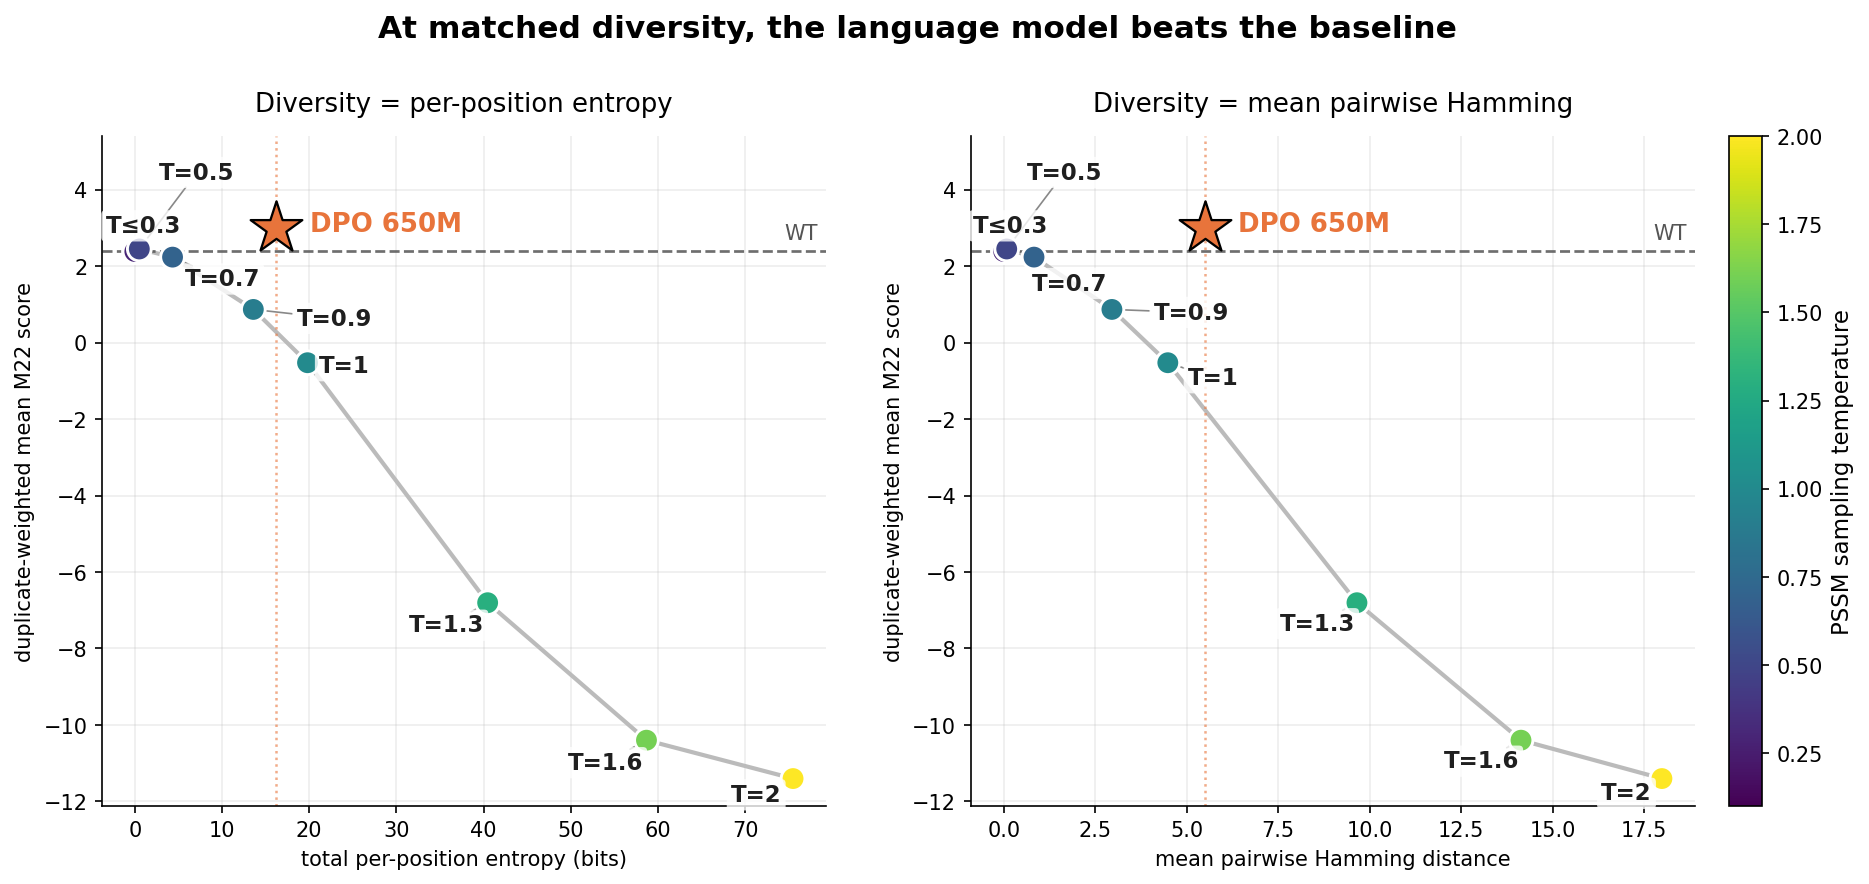

In [43]:
# Styled quality-vs-diversity frontier: PSSM curve (colour = temperature) with
# the single DPO point overlaid, under two diversity metrics. Temperature labels
# are auto-placed with adjustText (repelled, with short leader lines) so they
# stay next to their dot without overlapping.
from adjustText import adjust_text

DPO_C, WT_C, LINE_C = '#E8743B', '#555555', '#BBBBBB'
cmap = plt.cm.viridis
tmin, tmax = pssm_div['temperature'].min(), pssm_div['temperature'].max()

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14.5, 5.8))
panels = [(axA, 'entropy_bits', 'total per-position entropy (bits)', dpo_H,
           'Diversity = per-position entropy'),
          (axB, 'pairwise_hamming', 'mean pairwise Hamming distance', dpo_PH,
           'Diversity = mean pairwise Hamming')]
sc_last = None
for ax, xcol, xlab, dval, title in panels:
    d = pssm_div.sort_values(xcol).reset_index(drop=True)
    ax.plot(d[xcol], d['mean_score'], '-', color=LINE_C, lw=2.0, zorder=2)
    sc_last = ax.scatter(d[xcol], d['mean_score'], c=d['temperature'], cmap=cmap,
                         vmin=tmin, vmax=tmax, s=130, edgecolor='white',
                         linewidth=1.4, zorder=3)
    ax.scatter([dval], [dpo_q], marker='*', s=680, color=DPO_C, edgecolor='black',
               linewidth=1.1, zorder=6)
    ax.annotate('DPO 650M', (dval, dpo_q), fontsize=12.5, fontweight='bold',
                color=DPO_C, xytext=(16, 2), textcoords='offset points', va='center')
    ax.axvline(dval, color=DPO_C, ls=':', lw=1.2, alpha=0.6)
    if WT_SCORER is not None:
        ax.axhline(WT_SCORER, color=WT_C, ls='--', lw=1.3, alpha=0.85)
        ax.annotate('WT', (ax.get_xlim()[1], WT_SCORER), fontsize=10, color=WT_C,
                    xytext=(-4, 4), textcoords='offset points', ha='right', va='bottom')
    ax.set_ylim(ax.get_ylim()[0], 5.4)  # headroom above the top points for labels

    # one label per point; the coincident T<=0.3 points collapse to a single tag.
    low = d[d['temperature'] <= 0.3]
    pts = [(low[xcol].mean(), low['mean_score'].mean(), 'T≤0.3')]
    pts += [(r[xcol], r['mean_score'], f"T={r['temperature']:g}")
            for _, r in d[d['temperature'] > 0.3].iterrows()]
    texts = [ax.text(x, y, lab, fontsize=11, fontweight='bold', color='#1f1f1f',
                     ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.8))
             for x, y, lab in pts]
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='-', color='#888888', lw=0.8),
                expand=(1.5, 2.0), force_text=(0.6, 1.0),
                only_move={'static': 'xy', 'text': 'xy', 'explode': 'xy'})

    ax.set_xlabel(xlab)
    ax.set_ylabel('duplicate-weighted mean M22 score')
    ax.set_title(title, fontsize=12.5, pad=12)
    ax.grid(True, alpha=0.22, zorder=0)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)

cbar = fig.colorbar(sc_last, ax=[axA, axB], fraction=0.035, pad=0.02)
cbar.set_label('PSSM sampling temperature', fontsize=11)
fig.suptitle('At matched diversity, the language model beats the baseline',
             fontsize=15, fontweight='bold', y=1.02)
save_show_fig(fig, 'pssm_dpo_quality_vs_diversity')


**Result — the PLM dominates the baseline's entire frontier.** Reading the DPO
star against the grey PSSM curve:

- **At matched diversity, DPO wins by a wide margin.** DPO's library has entropy
  ≈ **13.6 bits** / mean pairwise Hamming ≈ **4.4**, essentially the same as the
  PSSM at `T = 0.9` (13.5 bits) and `T = 1.0` (4.5). At that *same* diversity the
  PSSM averages **0.85** (entropy-matched) / **−0.54** (Hamming-matched) versus
  DPO's **3.54** — a gap of **+2.7 to +4.1** scorer units.
- **DPO beats the PSSM at *every* diversity, not just the matched point.** The
  PSSM frontier never rises above ≈ **2.45**, and it only reaches that by
  collapsing to ~zero diversity (i.e. to WT). DPO scores **3.54 while holding
  substantial diversity**, so its point sits above the whole curve — there is no
  temperature at which the baseline catches up.
- **This is the epistasis gap, made fair.** The earlier "score falls as you move
  from WT" story could be dismissed as DPO simply moving less; here diversity is
  explicitly equalised, and the baseline still loses. The only way the PSSM
  reaches WT-level quality is to *stop being diverse*; the PLM achieves higher
  quality **and** diversity **and** distance from WT at once, because it samples
  coordinated (epistatic) edits rather than independent per-position draws.

This is the cleanest statement of the comparison: **at equal library diversity,
the language model's designs are scored markedly higher than the naive
per-position baseline's.**

## Discussion

All "scores" below are **M22-scorer predictions** (in scorer units), not
experimental measurements. The reference threshold is the scorer's own
prediction for the WT CDR-H3, **2.384** (the experimental WT enrichment, 5.19,
is a different scale and is not used here).

### 1. The scorer strongly prefers DPO
| set | n | mean | median | frac > WT (2.384) |
|---|---|---|---|---|
| **DPO 650M** | 1796 | **3.51** | **3.57** | **94.6 %** |
| PSSM (T=0.9) | 1182 | −0.16 | 1.70 | 32.1 % |
| ed2_m22 test (ref) | 27 535 | −8.09 | −11.06 | 4.2 % |

DPO puts essentially its **entire** output above the scorer's WT prediction
(95 %), versus a third for the PSSM and only 4 % of the natural (unselected) DMS
test set. The PSSM does clear a low bar — its median (1.70) sits well above the
DMS reference — confirming that simply matching per-position frequencies of good
binders already beats random natural variants. But it lands *below* WT on
average, whereas DPO sits a full ~1.2 scorer units above WT at the median.

### 2. The two generators explore sequence space very differently
- **PSSM stays local and undirected:** median edit distance from WT = **1**, and
  its mutations are **thinly spread** across the loop (max per-position mutation
  frequency = **0.17** — no single position is changed in more than ~1 in 6
  sequences). It nibbles a little everywhere.
- **DPO moves further and edits decisively:** median edit distance = **3**, with
  mutations **concentrated** on a few positions (max per-position mutation
  frequency = **0.86**; hotspots at positions **2, 8, 9**). It has learned which
  positions matter and commits to them, leaving the rest at WT.

### 3. The decisive difference is *score vs distance* (epistasis)
This is the key plot. As sequences move away from WT:
- **DPO holds or improves** its score — median ≈ 3.0 at 1 mutation rising to
  ≈ 3.8 at 4 mutations.
- **PSSM degrades sharply** — median ≈ 1.8 at 1 mutation collapsing to ≈ −3.7 at
  5 mutations.

Interpretation: the PSSM's extra mutations are, on average, **deleterious**,
because independent per-position sampling stacks individually-plausible changes
that are jointly bad — it cannot see epistasis. DPO's extra mutations are
**coordinated and beneficial**, evidence that the model captures the couplings
the PSSM is blind to. This is the concrete payoff of "modelling + search" over
"per-position statistics".

### 4. DPO is also more novel — it is not just memorising
- **Novelty:** **71 %** of DPO's unique sequences are absent from every DMS
  dataset, vs **34 %** for the PSSM (which, sampling near WT, frequently
  re-derives already-seen single/double mutants).
- **Top hits:** DPO's top-15 (scores up to **5.01**) are **almost entirely
  novel** (only 1 of 15 appears in any dataset), reached at 3–5 mutations. The
  PSSM's top-15 (up to 4.47) are mostly **already-seen** low-distance variants
  (≈ 2 mutations, several flagged `exp`/`ed2`). So DPO is generalising to new
  high-scoring sequences, not recombining known ones.

### Caveats
- **Scorer, not assay.** Everything rests on the M22 in-silico oracle. DPO and
  the scorer were trained on related data, so there is a real risk of
  **correlated optimism** — the model may be exploiting the scorer's blind spots.
  The headline numbers are a hypothesis to be **validated experimentally**, not a
  measured affinity.
- **Reference role.** The `ed2_m22` test split scores low (4 % above WT) by
  design — it is the full *unselected* DMS, dominated by poor binders. It anchors
  the scale; it is not a competing generator.
- **Unequal N / duplicates.** The PSSM yields fewer unique sequences (1182 vs
  1796) because near-WT sampling collides on duplicates; distributions are
  comparable but the counts differ.
- **Bounded search.** Beam search here is `B = 500`, `N = 5`, `T = 0.9`, seed 42.
  DPO's reachable space (and its score-vs-distance trend beyond 5 mutations) may
  shift with more steps or a different temperature.

### Bottom line
The PSSM baseline establishes that per-position frequencies of good binders get
you **modestly above the natural distribution and close to WT**, but cannot
venture far without losing predicted affinity. **DPO 650M + beam search produces
sequences the scorer rates far higher (95 % above WT), further from WT (median 3
mutations), and largely novel (71 %)** — consistent with a model that has learned
coordinated, epistatic edits rather than independent position preferences. The
clear next step is **experimental validation of the top DPO candidates**, since
the entire comparison is scorer-based.

## Second scorer — ModelArcEnsemble uncertainty scorer (Lorenz)

A second, independent opinion on the generated designs, from Lorenz Kaiser's
**uncertainty scorer** (`uncertainty_protein`, branch `Lorenz`). Where the M22
esme scorer is a single ESM2-based regressor, this is a **6-member
heterogeneous deep ensemble** (3 MLPs + 3 CNNs) trained on the
`Chen-2026 / C05_M22_ED5` DMS with a one-hot encoding of the 24-residue CDR-H3.
Each member outputs a (mean, log-std) pair, so the ensemble returns not just a
point prediction but an **uncertainty decomposition**:

- **`pred`** — ensemble-mean predicted `binding_enrichment_adj` (the "score",
  analogous to the M22 score but on this scorer's own scale).
- **`epistd`** — *epistemic* std: disagreement **between** the 6 members. High =
  the models extrapolate / haven't seen this region of sequence space → low
  confidence. This is the interesting one for novel designs.
- **`alestd`** — *aleatoric* std: the mean of each member's predicted noise →
  irreducible / data noise.
- **`totalstd`** = √(epistd² + alestd²).

Scoring runs through `scripts/analysis/score_sequences_with_uncertainty.py`,
which adapts our `cdrh3` CSVs to the scorer's schema, runs its `evaluate.py` in a
dedicated venv (`~/uncertainty_protein/.venv`, CPU), and writes a tidy
`cdrh3,pred,epistd,alestd,totalstd` CSV. As before, the notebook only preflights


### Preflight — uncertainty-scorer artifacts

Same pattern as the M22 preflight: the UQ score CSVs for the two generated sets.


In [44]:
# Uncertainty scorer (Lorenz / ModelArcEnsemble one-hot) score CSVs.
DPO_UQ_CSV  = SCORES_DIR / 'dpo_650m_step8250_filtered_uq.csv'
PSSM_UQ_CSV = SCORES_DIR / 'pssm_T0.9_uq.csv'
WT_UQ_CSV   = SCORES_DIR / 'wt_uq.csv'   # scorer's own prediction for the WT CDR-H3

uq_ok = [
    check_artifact(
        DPO_UQ_CSV,
        'UQ scores — DPO filtered set',
        f'sbatch bash_scripts/utils/score_generated_with_uncertainty.sbatch '
        f'--input-csv {BEAM_DPO_FILTERED} --output-csv {DPO_UQ_CSV}',
    ),
    check_artifact(
        PSSM_UQ_CSV,
        'UQ scores — PSSM T=0.9 set',
        f'sbatch bash_scripts/utils/score_generated_with_uncertainty.sbatch '
        f'--input-csv {PSSM_T09_CSV} --output-csv {PSSM_UQ_CSV}',
    ),
]
if not all(uq_ok):
    raise FileNotFoundError(
        'Missing UQ score artifact(s) above — submit the printed sbatch job(s), '
        'then re-run this notebook.'
    )
print('All UQ score artifacts present.')

[OK     ] UQ scores — DPO filtered set
          /cluster/scratch/mdenegri/protein-design/pssm_vs_dpo_650m/scores/dpo_650m_step8250_filtered_uq.csv

[OK     ] UQ scores — PSSM T=0.9 set
          /cluster/scratch/mdenegri/protein-design/pssm_vs_dpo_650m/scores/pssm_T0.9_uq.csv

All UQ score artifacts present.


In [45]:
dpo_uq  = pd.read_csv(DPO_UQ_CSV)    # columns: cdrh3, pred, epistd, alestd, totalstd
pssm_uq = pd.read_csv(PSSM_UQ_CSV)

dpo_u  = dpo_seqs.merge(dpo_uq,  on=GEN_SEQ_COL, how='inner')
pssm_u = pssm_seqs.merge(pssm_uq, on=GEN_SEQ_COL, how='inner')
print(f'UQ-scored — DPO: {len(dpo_u)}, PSSM: {len(pssm_u)}')

# Scorer's own prediction for WT (threshold for "better than WT", apples-to-apples).
WT_UQ = None
if WT_UQ_CSV.exists():
    WT_UQ = float(pd.read_csv(WT_UQ_CSV)['pred'].iloc[0])
    print(f'WT predicted (UQ scorer)  = {WT_UQ:.3f}')
else:
    print(f'[note] UQ WT prediction not found at {WT_UQ_CSV} — WT line omitted.')

UQ-scored — DPO: 3934, PSSM: 2647
WT predicted (UQ scorer)  = 7.211


### UQ predicted-score distributions

DPO vs PSSM under the ensemble scorer (its own scale, *not* comparable to the


Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/uq_score_distributions.pdf


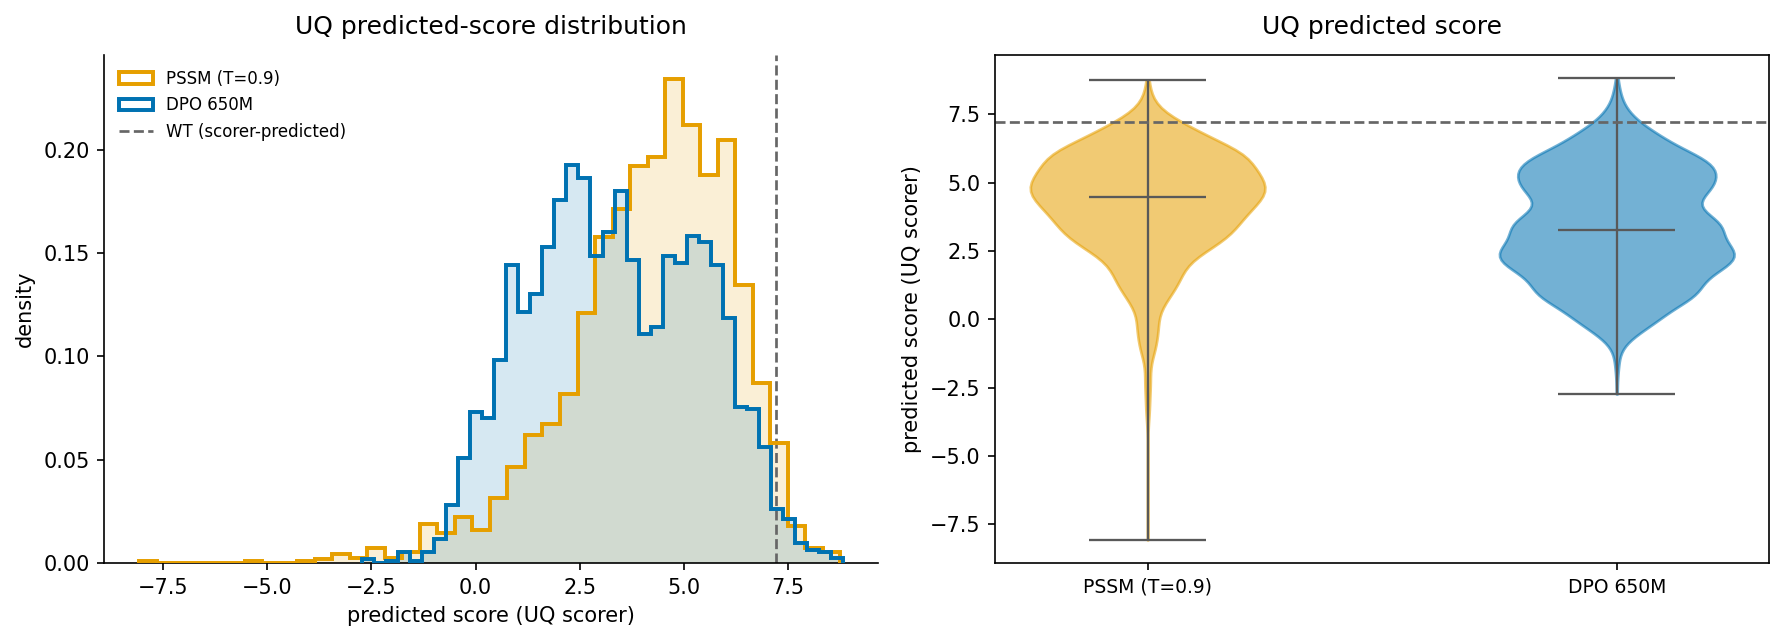

In [46]:
series_u = {
    'PSSM (T=0.9)': pssm_u['pred'].to_numpy(),
    'DPO 650M':     dpo_u['pred'].to_numpy(),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
for name, vals in series_u.items():
    c = MODEL_COLORS[name]
    ax1.hist(vals, bins=40, histtype='stepfilled', density=True, color=c, alpha=0.16, zorder=2)
    ax1.hist(vals, bins=40, histtype='step', density=True, color=c, linewidth=1.9, label=name, zorder=3)
if WT_UQ is not None:
    ax1.axvline(WT_UQ, color='0.4', linestyle='--', linewidth=1.3, label='WT (scorer-predicted)')
ax1.set_xlabel('predicted score (UQ scorer)'); ax1.set_ylabel('density')
ax1.legend(fontsize=8, frameon=False); ax1.set_title('UQ predicted-score distribution', pad=10)
ax1.spines[['top', 'right']].set_visible(False)

names = list(series_u)
parts = ax2.violinplot([series_u[n] for n in names], showmedians=True, showextrema=True)
for pc, n in zip(parts['bodies'], names):
    pc.set_facecolor(MODEL_COLORS[n]); pc.set_edgecolor(MODEL_COLORS[n]); pc.set_alpha(0.55); pc.set_linewidth(1.3)
for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
    if key in parts: parts[key].set_color('0.35'); parts[key].set_linewidth(1.1)
if WT_UQ is not None:
    ax2.axhline(WT_UQ, color='0.4', linestyle='--', linewidth=1.3)
ax2.set_xticks(range(1, len(names) + 1)); ax2.set_xticklabels(names, fontsize=9)
ax2.set_ylabel('predicted score (UQ scorer)'); ax2.set_title('UQ predicted score', pad=10)
fig.tight_layout()
save_show_fig(fig, 'uq_score_distributions')

### Do the two scorers agree?

Each generated CDR-H3 now has **two** independent predicted scores — M22 (esme)
and UQ (ensemble). If they agree, the M22 ranking is corroborated by a totally
different model class; if not, the designs sit where the two scorers disagree


Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/uq_vs_m22_agreement.pdf


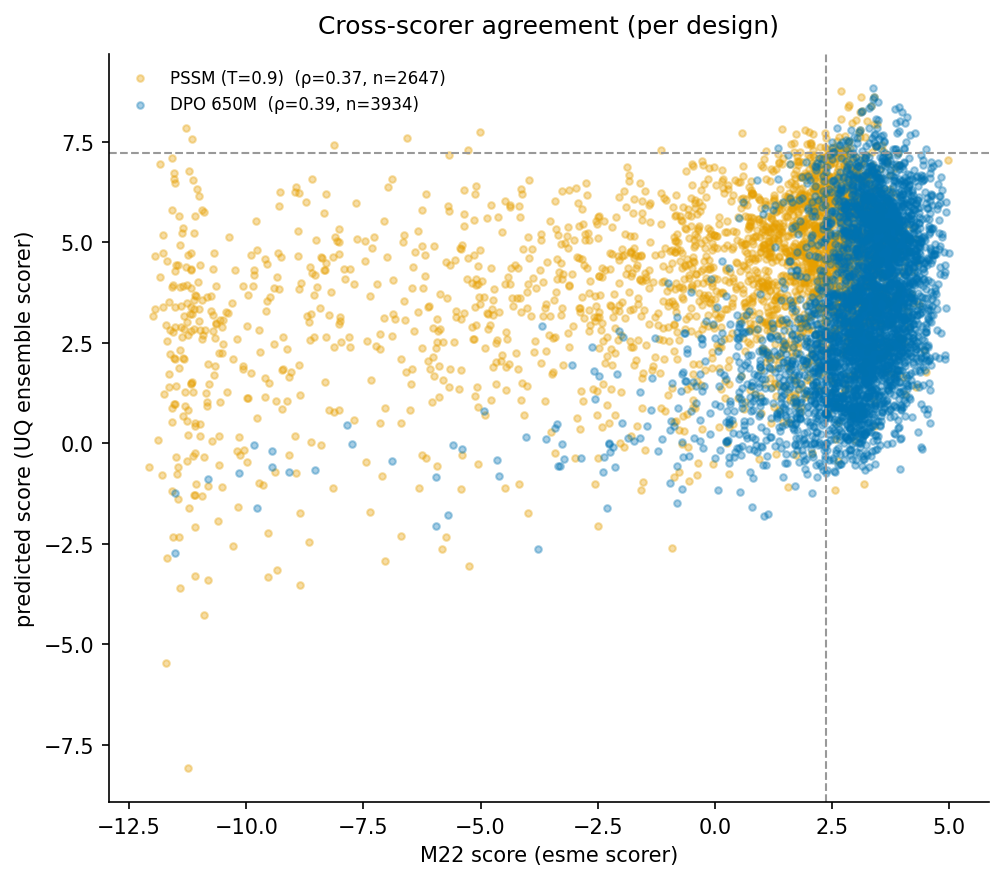

In [47]:
from scipy.stats import spearmanr

fig, ax = plt.subplots(figsize=(6.8, 6))
for name, u_df, m_df in [('PSSM (T=0.9)', pssm_u, pssm_m), ('DPO 650M', dpo_u, dpo_m)]:
    both = u_df[[GEN_SEQ_COL, 'pred']].merge(m_df[[GEN_SEQ_COL, 'score']], on=GEN_SEQ_COL, how='inner')
    if len(both) < 3:
        continue
    rho = spearmanr(both['score'], both['pred']).statistic
    ax.scatter(both['score'], both['pred'], s=10, alpha=0.35, color=MODEL_COLORS[name],
               label=f'{name}  (ρ={rho:.2f}, n={len(both)})')
if WT_SCORER is not None:
    ax.axvline(WT_SCORER, color='0.6', ls='--', lw=1.0)
if WT_UQ is not None:
    ax.axhline(WT_UQ, color='0.6', ls='--', lw=1.0)
ax.set_xlabel('M22 score (esme scorer)'); ax.set_ylabel('predicted score (UQ ensemble scorer)')
ax.set_title('Cross-scorer agreement (per design)', pad=10)
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'uq_vs_m22_agreement')

### Uncertainty — is DPO extrapolating?

DPO moves further from WT than the PSSM, so the ensemble may be **less
confident** about its designs (higher epistemic std) even when it scores them
highly. Left: total-uncertainty distributions. Right: epistemic uncertainty vs


Saved PDF: /cluster/home/mdenegri/protein-design/report/figures/pssm_vs_dpo_650m/uq_uncertainty.pdf


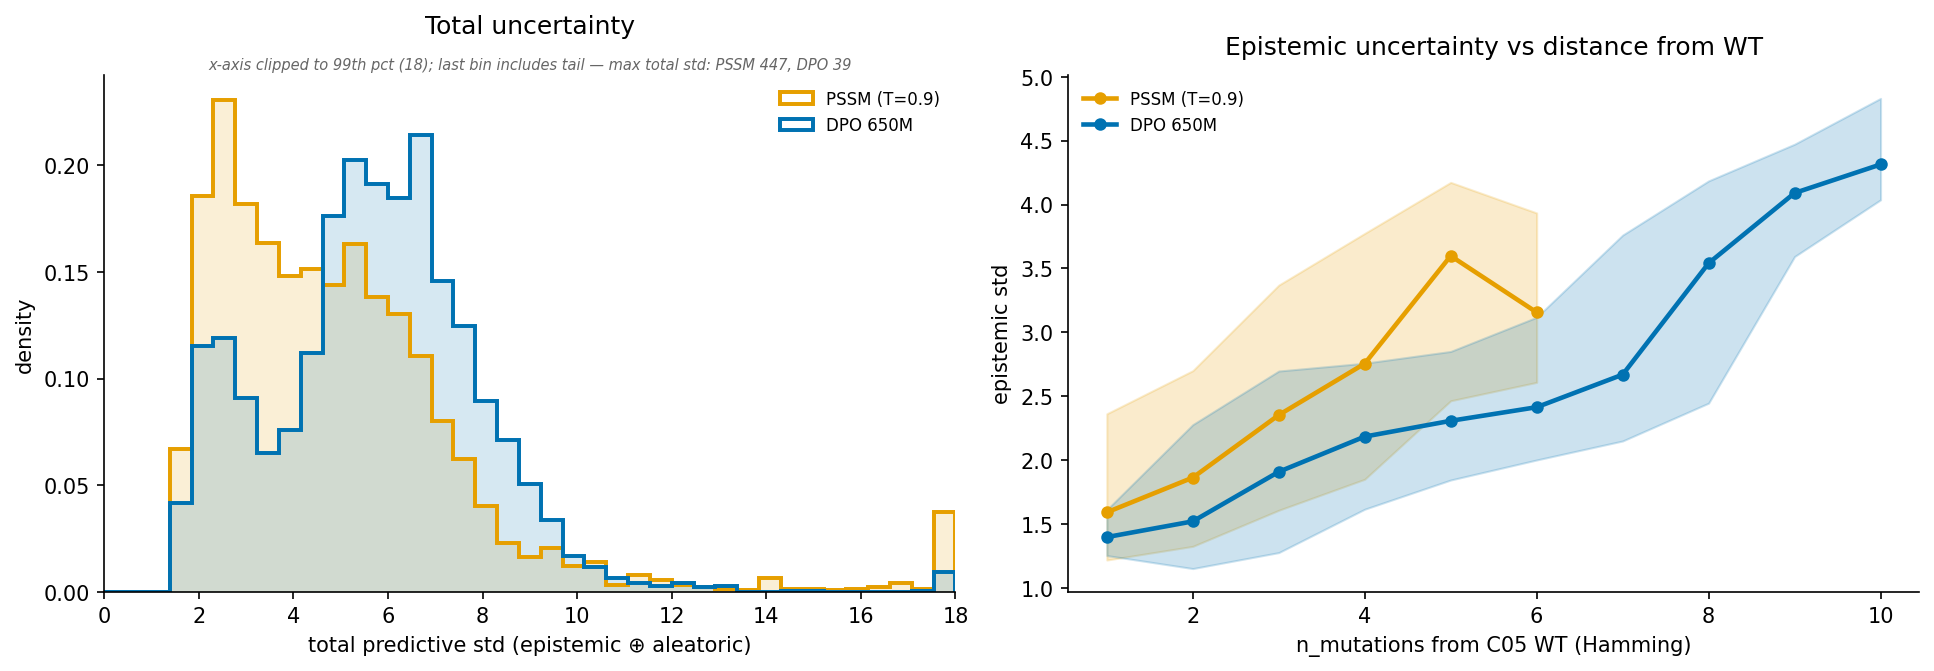

In [48]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# Left — total uncertainty distributions. A few designs have very large
# totalstd (rare high-epistemic blow-ups), so the x-axis is clipped to the
# combined 99th percentile and the rightmost bin accumulates the clipped tail.
tot = {name: u_df['totalstd'].to_numpy()
       for name, u_df in [('PSSM (T=0.9)', pssm_u), ('DPO 650M', dpo_u)]}
xcap = float(np.ceil(np.percentile(np.concatenate(list(tot.values())), 99)))
bins = np.linspace(0, xcap, 40)
for name, vals in tot.items():
    c = MODEL_COLORS[name]
    clipped = np.clip(vals, 0, xcap)
    axA.hist(clipped, bins=bins, histtype='stepfilled', density=True, color=c, alpha=0.16)
    axA.hist(clipped, bins=bins, histtype='step', density=True, color=c, linewidth=1.9, label=name)
axA.set_xlim(0, xcap)
axA.set_xlabel('total predictive std (epistemic ⊕ aleatoric)'); axA.set_ylabel('density')
axA.set_title('Total uncertainty', pad=20); axA.legend(fontsize=8, frameon=False)
maxstr = ', '.join(f'{n.split()[0]} {v.max():.0f}' for n, v in tot.items())
axA.text(0.5, 1.005,
         f'x-axis clipped to 99th pct ({xcap:.0f}); last bin includes tail — '
         f'max total std: {maxstr}',
         transform=axA.transAxes, ha='center', va='bottom',
         fontsize=7, style='italic', color='0.4')
axA.spines[['top', 'right']].set_visible(False)

# Right — epistemic uncertainty vs distance from WT.
for name, u_df in [('PSSM (T=0.9)', pssm_u), ('DPO 650M', dpo_u)]:
    c = MODEL_COLORS[name]
    stats = (u_df.groupby('n_mutations')['epistd']
             .agg(median='median', count='count',
                  q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75)))
    stats = stats[stats['count'] >= 10]
    if len(stats) == 0:
        continue
    axB.fill_between(stats.index, stats['q25'], stats['q75'], color=c, alpha=0.20)
    axB.plot(stats.index, stats['median'], '-o', color=c, lw=2.2, ms=5, label=name)
axB.set_xlabel('n_mutations from C05 WT (Hamming)'); axB.set_ylabel('epistemic std')
axB.set_title('Epistemic uncertainty vs distance from WT', pad=10)
axB.legend(fontsize=8, frameon=False); axB.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
save_show_fig(fig, 'uq_uncertainty')

### UQ summary table

Mean / median UQ `pred`, fraction above the scorer's WT prediction, and the


In [49]:
def uq_summary(name, df):
    row = {'set': name, 'n': len(df),
           'mean_pred': float(df['pred'].mean()),
           'median_pred': float(df['pred'].median()),
           'mean_epistd': float(df['epistd'].mean()),
           'mean_alestd': float(df['alestd'].mean()),
           'mean_totalstd': float(df['totalstd'].mean())}
    if WT_UQ is not None:
        row['frac_above_WT'] = float((df['pred'] > WT_UQ).mean())
    return row

uq_table = pd.DataFrame([uq_summary('PSSM (T=0.9)', pssm_u), uq_summary('DPO 650M', dpo_u)])
if WT_UQ is not None:
    print(f'Threshold — WT (UQ scorer-predicted) = {WT_UQ:.3f}')
display(uq_table.round(3))

Threshold — WT (UQ scorer-predicted) = 7.211


,set,n,mean_pred,median_pred,mean_epistd,mean_alestd,mean_totalstd,frac_above_WT
0,PSSM (T=0.9),2647,4.207,4.476,2.305,5.058,5.770,0.026
1,DPO 650M,3934,3.375,3.283,2.765,4.992,5.762,0.018


### Top-15 by UQ predicted score

Highest UQ-scoring designs per model, with their uncertainty, distance from WT,


In [50]:
def top_n_uq(u_df, annot, name, n=15):
    merged = u_df.merge(
        annot[[GEN_SEQ_COL, 'present_in_existing_dataset', 'matching_datasets']],
        on=GEN_SEQ_COL, how='left',
    )
    top = merged.sort_values('pred', ascending=False).head(n).reset_index(drop=True)
    top.insert(0, 'model', name)
    return top[['model', GEN_SEQ_COL, 'pred', 'epistd', 'totalstd', 'n_mutations',
                'present_in_existing_dataset', 'matching_datasets']]

print('Top 15 — PSSM (T=0.9)')
display(top_n_uq(pssm_u, pssm_annot, 'PSSM (T=0.9)').round(3))
print('Top 15 — DPO 650M')
display(top_n_uq(dpo_u, dpo_annot, 'DPO 650M').round(3))

Top 15 — PSSM (T=0.9)


,model,cdrh3,pred,epistd,totalstd,n_mutations,present_in_existing_dataset,matching_datasets
0,PSSM (T=0.9),HRSMQQVVSAGWERAVLVGDAFDV,8.764,1.607,2.841,2,True,ed2_si06:train;ed2_m22:train
1,PSSM (T=0.9),HRSMQQVVSAGWERADLVGDALDV,8.609,0.658,1.392,2,True,ed811_m22:train;ed2_m22:train;ed5_m22:train;ed...
2,PSSM (T=0.9),HRAMQQVVSAGWERADLVGDAFDV,8.602,2.075,3.656,2,True,ed2_si06:train;ed2_m22:train
3,PSSM (T=0.9),HRSMQQVVSAGWERAFLVGDAFDV,8.401,1.317,2.522,2,True,ed2_si06:train;ed2_m22:train
4,PSSM (T=0.9),HRSMQQVVSAGWERADLVGDAFDV,8.380,0.656,1.480,1,True,ed811_m22:train;ed2_m22:train;ed5_m22:train;ed...
5,PSSM (T=0.9),HRSMQQVVSAGWERRDLVGDAFDV,8.350,0.944,2.009,2,True,ed2_si06:train;ed2_m22:train
6,PSSM (T=0.9),HRSMQQVLSAGWERADLVGDAFDV,8.270,0.851,1.578,2,True,ed2_si06:train;ed2_m22:train
7,PSSM (T=0.9),HRSMQQVVSAGWERPDLVGDAFDV,8.223,1.021,1.878,2,True,ed2_si06:train;ed5_si06:train;ed2_m22:train;ed...
8,PSSM (T=0.9),HRSMQQVVSAGWERADLVGDAIDV,8.067,0.796,1.576,2,True,ed2_si06:train;ed2_m22:train
9,PSSM (T=0.9),HRSMQQVVSAGWERAKLVGDAFDV,8.026,0.599,2.650,2,False,


Top 15 — DPO 650M


,model,cdrh3,pred,epistd,totalstd,n_mutations,present_in_existing_dataset,matching_datasets
0,DPO 650M,HRSMQQVVSAGWERGDLVGDAFDV,8.834,0.610,1.394,2,True,ed811_m22:train;ed2_m22:train;ed5_m22:train;ed...
1,DPO 650M,HRSMQQVVSAGWERADLVGDALDV,8.609,0.658,1.392,2,True,ed811_m22:train;ed2_m22:train;ed5_m22:train;ed...
2,DPO 650M,HRSMQQVRSAGWERADLVGDAFDV,8.565,0.801,1.563,2,True,ed811_m22:train;ed2_m22:train;ed5_m22:train;ed...
3,DPO 650M,HRSMQQVVSAGWERAALVGDAFDV,8.492,1.569,2.845,2,True,ed2_si06:train;ed2_m22:train
4,DPO 650M,HRSMQQVVSAGWERADLVGDAFDV,8.380,0.656,1.480,1,True,ed811_m22:train;ed2_m22:train;ed5_m22:train;ed...
5,DPO 650M,HRSMQQVASAGWERGDLVGDAFDV,8.370,0.772,1.412,3,False,
6,DPO 650M,HRSMQQVASAGWERAVLVGDAFDV,8.329,1.614,2.545,3,False,
7,DPO 650M,HRSMQQVASAGWERAALVGDAFDV,8.302,1.776,2.650,3,False,
8,DPO 650M,HRSMQQVLSAGWERADLVGDAFDV,8.270,0.851,1.578,2,True,ed2_si06:train;ed2_m22:train
9,DPO 650M,HRSMQQVISAGWERADLVGDAFDV,8.235,0.798,1.546,2,True,ed2_si06:train;ed5_si06:train;ed2_m22:train;ed...
